# Creativity in vitro · Machine Learning Models - Binary Test Sun/Rest

**Author:** Lina Lopes  **Date:** 2025-06-26  

This notebook initiates the deep learning pipeline for the *Creativity in vitro* project (Session 3). It builds upon the preprocessed EEG dataset developed in Notebook 11, where alternating auditory instructions ("Imagine the sun on your face" and "Relax") were annotated as `sun_block` and `rest_block`, respectively.

**Objective**:  
To build a minimal end-to-end deep learning pipeline for binary classification of mental states (imagination vs. passive relaxation), using windowed EEG data.

**Pipeline outline**:

1. **Setup & Dataset Structure**  
   Load ICA-cleaned and annotated EEG data. Define sliding window parameters and organize labels.

2. **Data Preparation**  
   - Sliding window extraction (`X`)
   - Label encoding (`y`)
   - Normalization (Z-score)
   - Dataset splitting (e.g. Stratified K-Fold)
   - Class imbalance handling (optional)

3. **Deep Learning Modeling**  
   - Define EEGNet (or other architecture) in PyTorch  
   - Training loop with metrics and validation  
   - Save trained model and encoders

4. **Machine Learning Classic**

5. **Latent Feature Extraction**  
   Use intermediate model layers to extract learned EEG representations (embeddings), for visualization or further modeling.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# MNE
import mne
from mne import io
from mne import Epochs

# Machine Learning
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from collections import Counter
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from braindecode.models import EEGNetv4
import lightgbm as lgb

In [2]:
import torch
print(torch.__version__)
print("MPS available?", torch.backends.mps.is_available())

2.7.1
MPS available? True


### 1. Setup & Dataset Structure

In this section, we define the configuration dictionary (`CONFIG`) that holds paths, EEG metadata, and modeling parameters.

We then load the annotated and ICA-cleaned EEG block(s) defined in `selected_runs` using MNE. Each run is stored in a dictionary (`raws`) for flexible access. A quick shape summary and consistency check ensures the expected runs were loaded correctly.

Next, we define the EEG channels of interest from `CONFIG["data"]["eeg_ch"]`, excluding any known bad channels (currently empty). We retrieve their index positions (`picks`) and confirm the number of valid EEG channels available.

Finally, we inspect the annotations of the first run. As expected, the `.fif` file contains alternating segments labeled as `sun_block` and `rest_block`, corresponding to the two auditory instructions used during the recording. This confirms the dataset is structured and labeled correctly for further segmentation and modeling.


In [3]:
CONFIG = dict(
    paths = dict(
        bids_root   = Path("../bids_dataset"),
        annot_dir   = Path("../bids_dataset/derivatives/annotated/sub-lina/ses-03/eeg"),
        model_dir   = Path("../bids_dataset/derivatives/models"),
    ),
    data = dict(
        sfreq       = 250.0,                      # Hz
        eeg_ch      = ['F3', 'F4', 'C3', 'C4', 'P3',  'P4', 'Pz', 'Oz'],
        n_blocks    = 1,
        selected_runs = [1],
        label_map = {"rest_block": 0, "sun_block": 1},
    ),
    model = dict(
        cv_folds    = 5,            # number of StratifiedGroupKFold splits
    ),
)

# create necessary directories
for path in CONFIG["paths"].values():
    if path.suffix == "":  # skip CSV
        path.mkdir(parents=True, exist_ok=True)

print("Notebook-12 CONFIG defined and directories created 🚀")

Notebook-12 CONFIG defined and directories created 🚀


In [4]:
# Load only selected annotated EEG blocks into a dictionary
raws = {}
selected_runs = CONFIG['data']['selected_runs']

for block_id in selected_runs:
    fname = CONFIG['paths']['annot_dir'] / f'sub-lina_ses-03_task-sunimagery_run-{block_id:02d}_icaclean_annot.fif'
    raws[block_id] = io.read_raw_fif(fname, preload=True, verbose='ERROR')
    data = raws[block_id].get_data()
    print(f"Loaded block {block_id:02d}: {data.shape[0]} channels × {data.shape[1]} samples, {raws[block_id].times[-1]:.2f} s")

# Quick check: all expected blocks loaded
assert set(raws.keys()) == set(selected_runs), "Mismatch in number of blocks loaded"

# Print a short summary for confirmation
print(f"\nSelected {len(raws)} blocks loaded. Example block keys: {list(raws.keys())[:4]}")


Loaded block 01: 9 channels × 86001 samples, 344.00 s

Selected 1 blocks loaded. Example block keys: [1]


In [5]:
eeg_ch_names = CONFIG['data']['eeg_ch']
bad_chs = {}
eeg_ch_names = [ch for ch in eeg_ch_names if ch not in bad_chs]

first_raw = next(iter(raws.values()))  # generic way to access the first loaded run
all_ch_names = first_raw.ch_names

eeg_picks = [all_ch_names.index(ch) for ch in eeg_ch_names]
n_channels = len(eeg_picks)

print("EEG picks:", eeg_picks)
print("EEG channel names:", [all_ch_names[i] for i in eeg_picks])
print("Number of EEG channels:", n_channels)


EEG picks: [0, 1, 2, 3, 4, 5, 6, 7]
EEG channel names: ['F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'Pz', 'Oz']
Number of EEG channels: 8


In [6]:
# Inspect annotations from block
raw = next(iter(raws.values()))
annots = raw.annotations

print("Annotation descriptions:")
print(np.unique(annots.description))

print("\nFirst few annotations:")
for onset, duration, desc in zip(annots.onset[:10], annots.duration[:10], annots.description[:10]):
    print(f"Onset: {onset:.2f} s | Duration: {duration:.2f} s | Description: {desc}")


Annotation descriptions:
['rest_block' 'sun_block']

First few annotations:
Onset: 15.21 s | Duration: 6.35 s | Description: sun_block
Onset: 21.56 s | Duration: 5.08 s | Description: rest_block
Onset: 26.64 s | Duration: 6.35 s | Description: sun_block
Onset: 33.00 s | Duration: 5.08 s | Description: rest_block
Onset: 38.08 s | Duration: 6.35 s | Description: sun_block
Onset: 44.43 s | Duration: 5.08 s | Description: rest_block
Onset: 49.51 s | Duration: 6.35 s | Description: sun_block
Onset: 55.86 s | Duration: 5.08 s | Description: rest_block
Onset: 60.94 s | Duration: 6.35 s | Description: sun_block
Onset: 67.29 s | Duration: 5.08 s | Description: rest_block


## 2. Data Preparation
### 2.1 – Sliding Window Extraction

In this step, we segment the continuous EEG data into overlapping fixed-length windows suitable for training deep learning models.

We use a sliding window approach with the following parameters:

- **Window length**: 2.0 seconds  
- **Window hop**: 0.5 seconds (75% overlap)  
- **Sampling rate**: 250 Hz → each window contains 500 samples per channel

Each window is centered at a timestamp (`t_center`) and is included only if it falls entirely within a labeled annotation (`sun_block` or `rest_block`). This ensures that all extracted windows correspond unambiguously to a single mental state.

The resulting list of windows includes:
- Start sample index
- Window center time
- Associated label

This step expands the dataset, generating hundreds of short, labeled EEG segments from the original 60 annotated blocks. A visual quality check is included to ensure signal integrity and label consistency before moving to the modeling stage.


In [7]:
# Sliding Window Extraction for sun/rest blocks

window_length_s = 2.0
window_hop_s = 0.5
sfreq = raw.info['sfreq']
window_samples = int(window_length_s * sfreq)
window_hop_samples = int(window_hop_s * sfreq)

eeg_picks = mne.pick_types(raw.info, eeg=True)

all_windows = []

# Generate window centers along time
t_centers = np.arange(window_length_s/2, raw.times[-1] - window_length_s/2, window_hop_s)

for t_center in t_centers:
    # Check if this window is within a valid annotation
    label = None
    for ann in raw.annotations:
        if ann["onset"] <= t_center < ann["onset"] + ann["duration"]:
            label = ann["description"]
            break
    if label is None:
        continue  # window outside annotation

    # Calculate window start
    t_start = t_center - window_length_s/2
    start_sample = int(t_start * sfreq)
    if start_sample < 0 or (start_sample + window_samples) > raw.n_times:
        continue

    all_windows.append({
        "start_sample": start_sample,
        "center_sample": int(t_center * sfreq),
        "label": label,
        "t_center": t_center,
    })

# Check integrity
print("Checking window shapes...")
bad_windows = 0
for w in all_windows:
    seg = raw.get_data(picks=eeg_picks,
                       start=w['start_sample'],
                       stop=w['start_sample'] + window_samples)
    if seg.shape != (len(eeg_picks), window_samples):
        print(f"⚠️ Bad window at t={w['t_center']:.2f}s")
        bad_windows += 1

windows_df = pd.DataFrame(all_windows)
print(f"\n✅ Extracted {len(windows_df)} valid windows")
print(f"🧠 Labels: {windows_df['label'].value_counts().to_dict()}")


Checking window shapes...

✅ Extracted 655 valid windows
🧠 Labels: {'sun_block': 367, 'rest_block': 288}


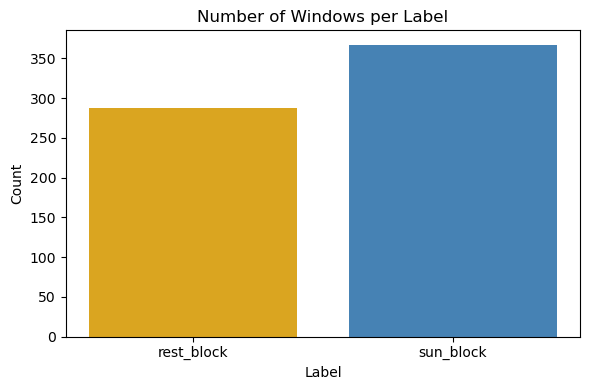

🧠 Window label distribution:
 label
rest_block    288
sun_block     367
Name: count, dtype: int64


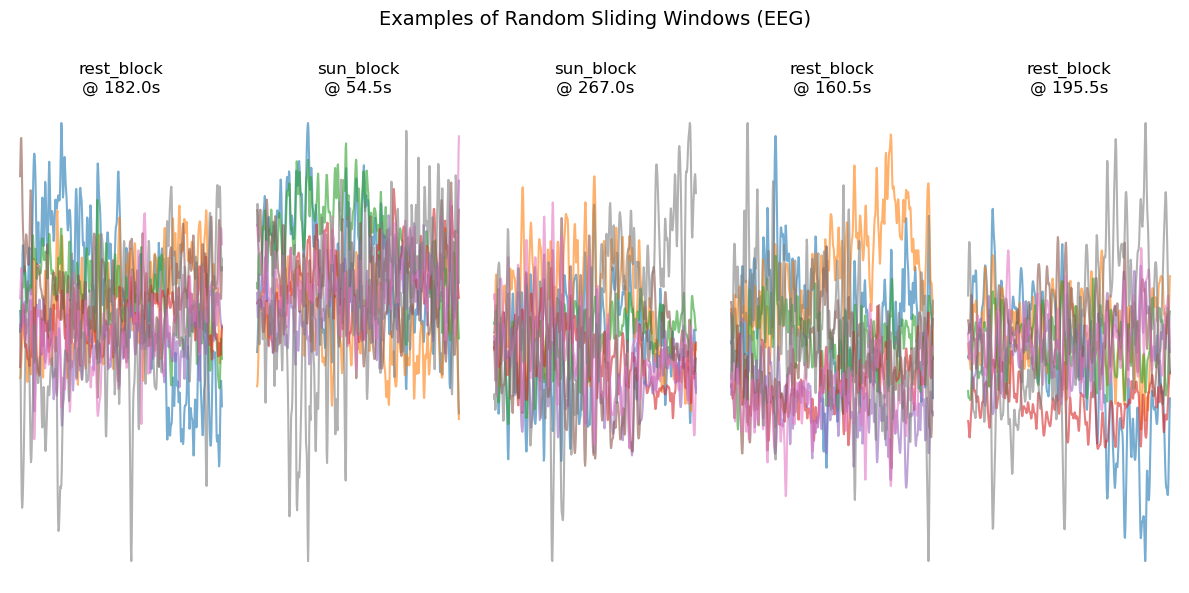

In [8]:
# Window/Label Distribution Summary & Visual QC

# --- Distribuição de labels (sun/rest) ---
label_counts = windows_df['label'].value_counts().sort_index()
plt.figure(figsize=(6,4))
plt.bar(label_counts.index, label_counts.values, color=["goldenrod", "steelblue"])
plt.xlabel('Label')
plt.ylabel('Count')
plt.title('Number of Windows per Label')
plt.tight_layout()
plt.show()

print("🧠 Window label distribution:\n", label_counts)

# --- Quick plot of 5 random windows for visual QC ---
np.random.seed(42)
sample_idx = np.random.choice(len(windows_df), 5, replace=False)

plt.figure(figsize=(12, 6))
for i, idx in enumerate(sample_idx, 1):
    row = windows_df.iloc[idx]
    start = row['start_sample']
    seg = raw.get_data(picks=eeg_picks,
                       start=start,
                       stop=start + window_samples)
    plt.subplot(1, 5, i)
    plt.plot(seg.T, alpha=0.6)
    plt.title(f"{row['label']}\n@ {row['t_center']:.1f}s")
    plt.axis('off')

plt.suptitle("Examples of Random Sliding Windows (EEG)", fontsize=14)
plt.tight_layout()
plt.show()


### 2.2 – Label Mapping & Grouping

We verify the distribution of labels in the extracted windows (`sun_block` and `rest_block`). A simple frequency count confirms that both classes are present in the dataset, ensuring that binary classification is feasible.

We keep the original `label` column for readability and debugging, and create a new column `y` with binary targets (`0 = rest_block`, `1 = sun_block`) using a label map. This ensures compatibility with machine learning and deep learning pipelines that require numeric class labels.


Counts of each label:
label
rest_block    288
sun_block     367
Name: count, dtype: int64


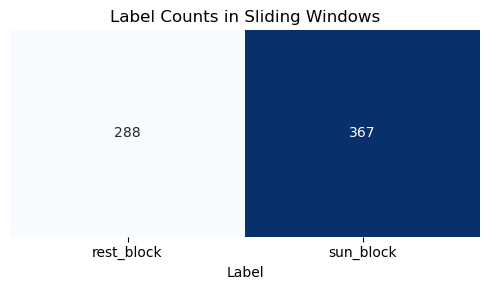

✅ Both labels present.


In [9]:
# Confirming Labels
windows_df["y"] = windows_df["label"].map(CONFIG["data"]["label_map"])

# Visualize count of windows per label (sun/rest)
label_counts = windows_df["label"].value_counts().sort_index()

print("Counts of each label:")
print(label_counts)

# Visualize as simple 1D heatmap
plt.figure(figsize=(5, 3))
sns.heatmap(label_counts.to_frame().T, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Label Counts in Sliding Windows")
plt.xlabel("Label")
plt.yticks([])  # remove y-axis index
plt.tight_layout()
plt.show()

# Verify: both labels are present
n_labels = label_counts.shape[0]
if n_labels < 2:
    print("⚠️ Warning: Only one label present in dataset.")
else:
    print("✅ Both labels present.")


### 2.3 – Dataset Splits

We split the dataset into training, validation, and test sets using stratified sampling to preserve the class distribution.

- First, we create an 80/20 split between train+val and test.
- Then, we split the train+val portion into 80% training and 20% validation.
- Stratification ensures each subset has a balanced number of `sun_block` and `rest_block` windows.
- A new column `split` is added to the main DataFrame to tag each window.

Label distributions for each split are visualized to confirm balance and integrity before training.


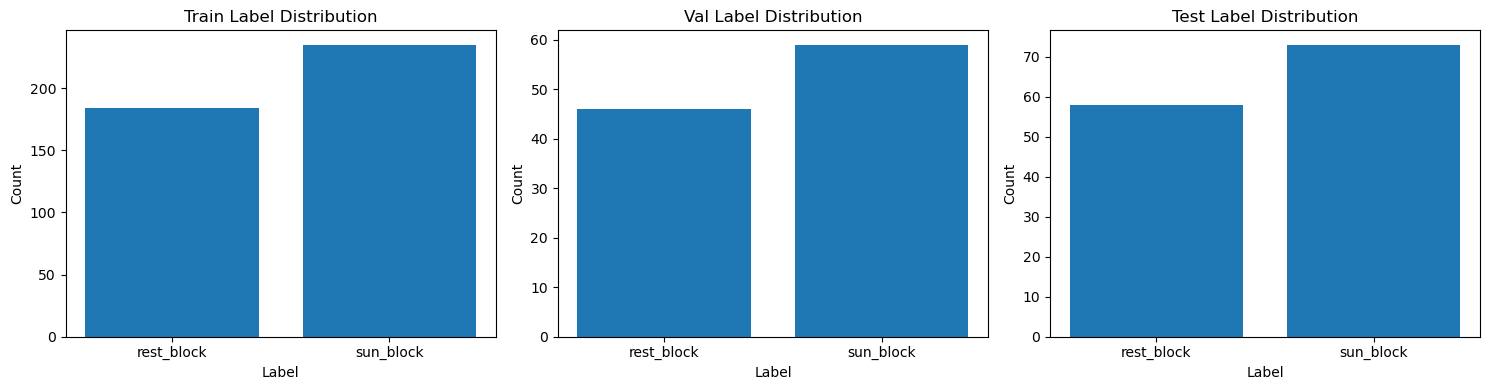

In [10]:
# Split Strategy: Stratified ShuffleSplit (no groups)

# a) Labels
y = windows_df["label"].values

# b) Initial split: trainval vs test
trainval_idx, test_idx = train_test_split(
    windows_df.index,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# c) Secondary split: train vs validation
y_trainval = y[trainval_idx]
train_idx, val_idx = train_test_split(
    trainval_idx,
    test_size=0.2,
    stratify=y_trainval,
    random_state=43
)

split_indices = {"train": train_idx, "val": val_idx, "test": test_idx}

# d) Assign splits to DataFrame
windows_df["split"] = "train"
windows_df.loc[val_idx,  "split"] = "val"
windows_df.loc[test_idx, "split"] = "test"

# e) Visualize label balance per split
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, split in zip(axes, ["train", "val", "test"]):
    counts = (windows_df[windows_df.split == split]["label"]
              .value_counts()
              .sort_index())
    ax.bar(counts.index, counts.values)
    ax.set_title(f"{split.capitalize()} Label Distribution")
    ax.set_xlabel("Label")
    ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


### 2.4 – Normalization (Z-Score)

To standardize the input data across trials and reduce inter-channel variability, we compute Z-score normalization based on the training set only.

- For each EEG channel, we calculate the mean and standard deviation across all training windows.
- A custom function applies the normalization to each segment by subtracting the mean and dividing by the standard deviation per channel.
- This normalization is applied consistently across training, validation, and test sets, using parameters computed from training data only.

A visual inspection of raw versus normalized signals confirms the transformation behaves as expected (mean ≈ 0, std ≈ 1).


In [11]:
print("Channel names:", next(iter(raws.values())).ch_names)
print("Channel types:", next(iter(raws.values())).get_channel_types())

Channel names: ['F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'Pz', 'Oz', 'stim']
Channel types: ['eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'stim']


In [12]:
# eeg_picks = [i for i, t in enumerate(raws[0].get_channel_types()) if t == 'eeg']
print("EEG picks:", eeg_picks)
print("Number of EEG channels:", len(eeg_picks))

EEG picks: [0 1 2 3 4 5 6 7]
Number of EEG channels: 8


In [13]:
# Compute Per-Channel Mean and Std on Training Windows

# Parameters
n_channels = len(eeg_picks)
window_samples = int(2.0 * sfreq)

# Filter only training windows
train_df = windows_df[windows_df['split'] == 'train']

# Extract EEG segments: (channels x samples x windows)
train_segments = []
for i, row in train_df.iterrows():
    seg = raw.get_data(picks=eeg_picks,
                       start=int(row['start_sample']),
                       stop=int(row['start_sample']) + window_samples)
    train_segments.append(seg)

train_data = np.stack(train_segments, axis=2)  # shape: channels x samples x windows

# Reshape to (channels, total_samples)
train_data_reshaped = train_data.reshape(n_channels, -1)

# Calculate mean and std per channel
channel_mean = train_data_reshaped.mean(axis=1)  # (n_channels,)
channel_std = train_data_reshaped.std(axis=1)

print("✅ Training set channel means (µV):\n", channel_mean)
print("📉 Channel stds (µV):\n", channel_std)
print("🧠 Shape (channels x samples x windows):", train_data.shape)


✅ Training set channel means (µV):
 [-2.56963303e-09  2.80534648e-09 -2.52073167e-09 -1.63241408e-09
 -2.47519857e-10  2.21686239e-09 -8.33048700e-10  2.78113852e-09]
📉 Channel stds (µV):
 [1.54982317e-07 1.70304667e-07 8.94714247e-08 1.05638880e-07
 1.08187983e-07 1.20773141e-07 1.01114332e-07 2.15358024e-07]
🧠 Shape (channels x samples x windows): (8, 500, 419)


In [14]:
# import joblib

# norm_stats = {
#     "channel_mean": channel_mean,
#     "channel_std": channel_std,
#     "eeg_ch_names": eeg_ch_names
# }

# norm_path = CONFIG["paths"]["model_dir"] / "normalization_stats.joblib"
# joblib.dump(norm_stats, norm_path)

# print(f"✅ Normalization parameters saved to: {norm_path}")


In [15]:
# Apply Z-Score Normalization to All Windows

# Function for fast normalization
def normalize_segment(seg, mean, std):
    # seg: shape (channels, samples)
    return (seg - mean[:, None]) / std[:, None]

# Example: apply normalization to first 5 windows
for idx in range(5):
    row = windows_df.iloc[idx]
    seg = raw.get_data(picks=eeg_picks,
                       start=int(row['start_sample']),
                       stop=int(row['start_sample']) + window_samples)
    seg_norm = normalize_segment(seg, channel_mean, channel_std)

    print(f"Window {idx} ({row['label']} @ {row['t_center']:.2f}s):")
    print("→ Mean per channel after norm:", seg_norm.mean(axis=1))
    print("→ Std per channel after norm:", seg_norm.std(axis=1))
    print("-" * 40)

Window 0 (sun_block @ 15.50s):
→ Mean per channel after norm: [ 0.19809106  0.36946312  0.50943676 -0.83466235  0.79713314 -0.05546855
 -0.30991981 -0.46078117]
→ Std per channel after norm: [0.91752545 0.78298697 1.22590259 1.06668809 0.97108264 1.18123394
 0.96734511 0.89794931]
----------------------------------------
Window 1 (sun_block @ 16.00s):
→ Mean per channel after norm: [ 0.18449287  0.06375295  0.80281127 -1.20320511  0.69916012  0.16573428
 -0.42453763 -0.17136171]
→ Std per channel after norm: [0.99004553 0.93039909 1.14740902 0.93305548 1.03117249 1.25817707
 1.03735797 1.0645857 ]
----------------------------------------
Window 2 (sun_block @ 16.50s):
→ Mean per channel after norm: [ 0.17460637 -0.28331688  1.00617994 -1.33527384  0.61814422  0.30955568
 -0.42908031  0.05268506]
→ Std per channel after norm: [0.95007664 0.79158837 1.07335783 0.75315911 0.89866188 1.05393361
 0.99320108 1.0715313 ]
----------------------------------------
Window 3 (sun_block @ 17.00s):


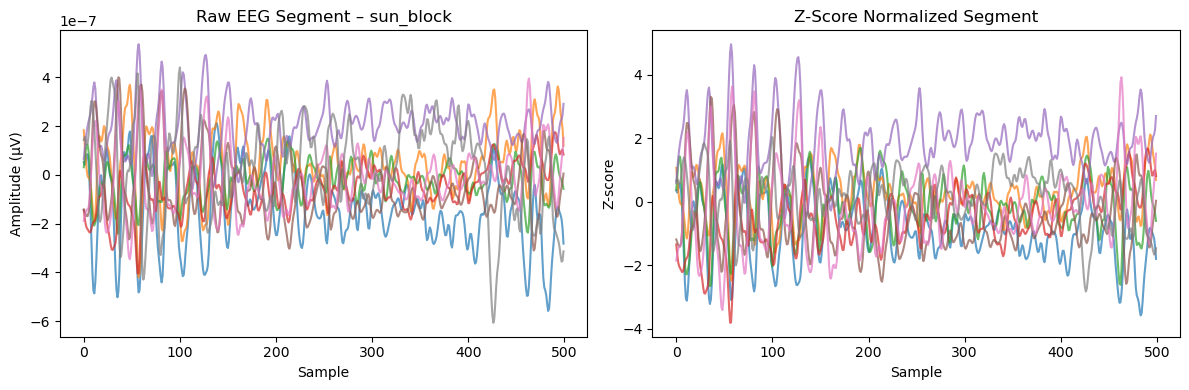

In [16]:
# Visual Check: Distribution Before/After Normalization

# Select a random training window
rand_idx = train_df.sample(1, random_state=0).index[0]
row = windows_df.loc[rand_idx]

# Extract raw segment
seg = raw.get_data(picks=eeg_picks,
                   start=int(row['start_sample']),
                   stop=int(row['start_sample']) + window_samples)

# Normalize
seg_norm = normalize_segment(seg, channel_mean, channel_std)

# Plot
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(seg.T, alpha=0.7)
plt.title(f"Raw EEG Segment – {row['label']}")
plt.xlabel("Sample")
plt.ylabel("Amplitude (µV)")

plt.subplot(1, 2, 2)
plt.plot(seg_norm.T, alpha=0.7)
plt.title("Z-Score Normalized Segment")
plt.xlabel("Sample")
plt.ylabel("Z-score")

plt.tight_layout()
plt.show()


### 2.5 – Class Balance

To address potential class imbalance during training, we compute inverse-frequency weights for each class based on the training set distribution.

- Class labels are first mapped to integers (e.g., `rest_block = 0`, `sun_block = 1`)
- Class frequencies are computed from the training subset
- Inverse-frequency weights are calculated and normalized to sum to the number of classes
- These weights are stored as a PyTorch tensor and will be passed to `CrossEntropyLoss` during model training

Visualizations of both the raw class frequencies and the computed weights are provided to validate the process and help assess whether balancing is necessary.


In [17]:
# Class Imbalance: Compute Class Weights for CrossEntropyLoss (simplified)

# Extract training labels (already as integers 0 and 1)
y_train_idx = windows_df.loc[windows_df["split"] == "train", "y"].values

# Frequencies and inverse-frequency weights
classes, counts = np.unique(y_train_idx, return_counts=True)
freqs = counts / counts.sum()
inv_freq = 1.0 / freqs
class_weights = inv_freq / inv_freq.sum() * len(classes)

# PyTorch tensor for loss function
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weights_tensor = torch.tensor(class_weights, dtype=torch.float32, device=device)

# Label mapping (for reference)
index_to_label = {0: "rest_block", 1: "sun_block"}

# Print results
print("Train set class frequencies:")
for c, n in zip(classes, counts):
    print(f"Label {index_to_label[c]} (index {c}): {n} windows")

print("\nClass weights (for CrossEntropyLoss):", class_weights)
print("Label mapping:", index_to_label)


Train set class frequencies:
Label rest_block (index 0): 184 windows
Label sun_block (index 1): 235 windows

Class weights (for CrossEntropyLoss): [1.12171838 0.87828162]
Label mapping: {0: 'rest_block', 1: 'sun_block'}


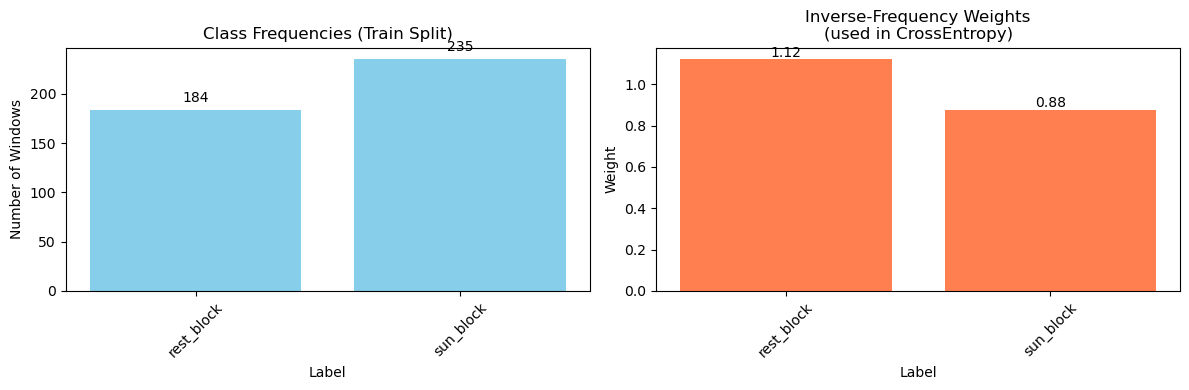

In [18]:
# Visualize class frequencies and weights (Train Split)

labels = list(index_to_label.keys())      # [0, 1]
label_names = [index_to_label[i] for i in labels]
freqs = counts                            # computed above
weights = class_weights                   # computed above

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Frequencies
axes[0].bar(labels, freqs, color='skyblue')
axes[0].set_title("Class Frequencies (Train Split)")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Number of Windows")
axes[0].set_xticks(labels)
axes[0].set_xticklabels(label_names, rotation=45)
for i, v in enumerate(freqs):
    axes[0].text(labels[i], v + 8, str(v), ha='center')

# Weights
axes[1].bar(labels, weights, color='coral')
axes[1].set_title("Inverse-Frequency Weights\n(used in CrossEntropy)")
axes[1].set_xlabel("Label")
axes[1].set_ylabel("Weight")
axes[1].set_xticks(labels)
axes[1].set_xticklabels(label_names, rotation=45)
for i, w in enumerate(weights):
    axes[1].text(labels[i], w + 0.01, f"{w:.2f}", ha='center')

plt.tight_layout()
plt.show()

## 3. Deep Learning Modeling
### 3.1 – EEGNet Model Definition

We define the EEGNet architecture (PyTorch), adapted for binary classification of short EEG segments (2-second sliding windows).

This implementation uses a reduced version of EEGNet to better match the scale and complexity of the dataset:

- Fewer convolutional filters (4→8→8) to reduce risk of overfitting
- Higher dropout rate (0.5) for regularization
- Dynamic flattening to support different input sizes
- Compatible with raw EEG input shape: (batch, channels, samples)

The model is instantiated using the number of EEG channels, the window length in samples, and the number of classes (2). A test forward pass confirms output shape and sanity of the architecture.


In [19]:
# PyTorch Dataset: Sliding Window EEG

class EEGWindowDataset(Dataset):
    def __init__(self, df, split, raw, eeg_picks, window_samples, channel_mean, channel_std):
        # Filter windows by split
        self.df = df[df["split"] == split].reset_index(drop=True)
        self.raw = raw
        self.eeg_picks = eeg_picks
        self.window_samples = window_samples
        self.mean = torch.tensor(channel_mean, dtype=torch.float32)[:, None]
        self.std  = torch.tensor(channel_std,  dtype=torch.float32)[:, None]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        start = int(row["start_sample"])
        seg = self.raw.get_data(
            picks=self.eeg_picks,
            start=start,
            stop=start + self.window_samples
        )
        # Normalization
        seg = (torch.from_numpy(seg).float() - self.mean) / self.std
        x = seg
        y = torch.tensor(row["y"], dtype=torch.long)
        return x, y

print("✅ EEGWindowDataset class adapted.")

✅ EEGWindowDataset class adapted.


In [20]:
# DataLoader for Each Split
batch_size = 64

# Label mapping defined previously
# label_to_index = {'rest_block': 0, 'sun_block': 1} (for example)

train_dataset = EEGWindowDataset(windows_df, "train", raw, eeg_picks, window_samples, channel_mean, channel_std)
val_dataset   = EEGWindowDataset(windows_df, "val",   raw, eeg_picks, window_samples, channel_mean, channel_std)
test_dataset  = EEGWindowDataset(windows_df, "test",  raw, eeg_picks, window_samples, channel_mean, channel_std)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

# Check batch shape
x_batch, y_batch = next(iter(train_loader))
print(f"🧠 Train batch shape: {x_batch.shape} (batch, channels, samples)")
print(f"🎯 Train labels shape: {y_batch.shape} (batch)")


🧠 Train batch shape: torch.Size([64, 8, 500]) (batch, channels, samples)
🎯 Train labels shape: torch.Size([64]) (batch)


In [21]:
class EEGNet(nn.Module):
    def __init__(self, n_channels=len(eeg_picks), n_samples=250, n_classes = windows_df["y"].nunique()):
        super().__init__()
        self.firstconv = nn.Conv2d(1, 4, (1, 64), padding=(0, 32), bias=False)
        self.firstbn = nn.BatchNorm2d(4)

        self.depthwise = nn.Conv2d(4, 8, (n_channels, 1), groups=4, bias=False)
        self.depthbn = nn.BatchNorm2d(8)

        self.separable = nn.Conv2d(8, 8, (1, 16), padding=(0, 8), bias=False)
        self.sepbn = nn.BatchNorm2d(8)

        self.pool = nn.AvgPool2d((1, 4))
        self.drop = nn.Dropout(0.5)

        # Dynamically compute flatten dimension
        with torch.no_grad():
            x = torch.zeros(1, 1, n_channels, n_samples)
            x = self.firstconv(x)
            x = self.firstbn(x)
            x = nn.functional.elu(x)
            x = self.depthwise(x)
            x = self.depthbn(x)
            x = nn.functional.elu(x)
            x = self.pool(x)
            x = self.drop(x)
            x = self.separable(x)
            x = self.sepbn(x)
            x = nn.functional.elu(x)
            x = self.pool(x)
            x = self.drop(x)
            flat_dim = x.flatten(start_dim=1).shape[1]

        self.classify = nn.Linear(flat_dim, n_classes)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.firstconv(x)
        x = self.firstbn(x)
        x = nn.functional.elu(x)
        x = self.depthwise(x)
        x = self.depthbn(x)
        x = nn.functional.elu(x)
        x = self.pool(x)
        x = self.drop(x)
        x = self.separable(x)
        x = self.sepbn(x)
        x = nn.functional.elu(x)
        x = self.pool(x)
        x = self.drop(x)
        x = x.flatten(start_dim=1)
        x = self.classify(x)
        return x

print("✅ EEGNet (reduced) model class defined.")

✅ EEGNet (reduced) model class defined.


In [22]:
# Test Forward Pass on Dummy Batch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = EEGNet(n_channels=n_channels, n_samples=window_samples, n_classes = windows_df["y"].nunique()).to(device)

x_batch, y_batch = next(iter(train_loader))
x_batch = x_batch.to(device)
y_batch = y_batch.to(device)

with torch.no_grad():
    out = model(x_batch)

print(f"✅ Model output shape: {out.shape} (batch, n_classes)")
print(f"🧮 First 5 predictions (logits):\n{out[:5]}")

✅ Model output shape: torch.Size([64, 2]) (batch, n_classes)
🧮 First 5 predictions (logits):
tensor([[ 0.4125,  0.1533],
        [ 0.1468, -0.0898],
        [-0.1000, -0.4995],
        [ 0.2814,  0.5629],
        [ 0.6561, -0.0768]])


### 3.2 – Training & Validation Loop

We train the EEGNet model using cross-entropy loss with inverse-frequency class weights, the Adam optimizer, and a learning rate scheduler (`ReduceLROnPlateau`). The training procedure includes:

- **Batch-wise training** on sliding-window EEG segments
- **Validation balanced accuracy** monitoring per epoch
- **Early stopping** with a patience of 10 epochs to avoid overfitting
- **Learning rate decay** triggered by plateauing validation performance

The model with the best validation accuracy is saved and restored at the end of training.

A training curve is plotted showing the progression of loss and validation balanced accuracy across epochs.


In [23]:
def eval_model(model, data_loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in data_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            preds = out.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(yb.cpu().numpy())
    acc = balanced_accuracy_score(all_labels, all_preds)
    return acc, all_labels, all_preds


In [24]:
from copy import deepcopy
import torch.optim as optim
import torch.nn as nn

num_epochs = 100
patience = 10
best_val_acc = 0
epochs_no_improve = 0
train_losses = []
val_accs = []

optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=5, factor=0.5)
criterion = nn.CrossEntropyLoss(weight=weights_tensor.to(device))

best_model_state = deepcopy(model.state_dict())

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
    avg_loss = running_loss / len(train_loader.dataset)
    train_losses.append(avg_loss)

    val_acc, _, _ = eval_model(model, val_loader, device)
    val_accs.append(val_acc)
    scheduler.step(val_acc)

    print(f"Epoch {epoch+1}: Train loss={avg_loss:.4f} | Val bal-acc={val_acc:.3f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
    if epochs_no_improve >= patience:
        print(f"⏹️ Early stopping at epoch {epoch+1}. Best val bal-acc={best_val_acc:.3f}")
        break

model.load_state_dict(best_model_state)
print("✅ Best model loaded from validation.")
print(f"Epoch {epoch+1}: Train loss={avg_loss:.4f} | Val bal-acc={val_acc:.3f} | LR={optimizer.param_groups[0]['lr']:.1e}")


Epoch 1: Train loss=0.6806 | Val bal-acc=0.617
Epoch 2: Train loss=0.6388 | Val bal-acc=0.671
Epoch 3: Train loss=0.6142 | Val bal-acc=0.683
Epoch 4: Train loss=0.5871 | Val bal-acc=0.717
Epoch 5: Train loss=0.5789 | Val bal-acc=0.723
Epoch 6: Train loss=0.5516 | Val bal-acc=0.734
Epoch 7: Train loss=0.5528 | Val bal-acc=0.770
Epoch 8: Train loss=0.5566 | Val bal-acc=0.751
Epoch 9: Train loss=0.5318 | Val bal-acc=0.755
Epoch 10: Train loss=0.5384 | Val bal-acc=0.787
Epoch 11: Train loss=0.5040 | Val bal-acc=0.776
Epoch 12: Train loss=0.5277 | Val bal-acc=0.785
Epoch 13: Train loss=0.5021 | Val bal-acc=0.809
Epoch 14: Train loss=0.5021 | Val bal-acc=0.781
Epoch 15: Train loss=0.5015 | Val bal-acc=0.779
Epoch 16: Train loss=0.4884 | Val bal-acc=0.798
Epoch 17: Train loss=0.4974 | Val bal-acc=0.768
Epoch 18: Train loss=0.5187 | Val bal-acc=0.779
Epoch 19: Train loss=0.4826 | Val bal-acc=0.776
Epoch 20: Train loss=0.4901 | Val bal-acc=0.807
Epoch 21: Train loss=0.4832 | Val bal-acc=0.779
E

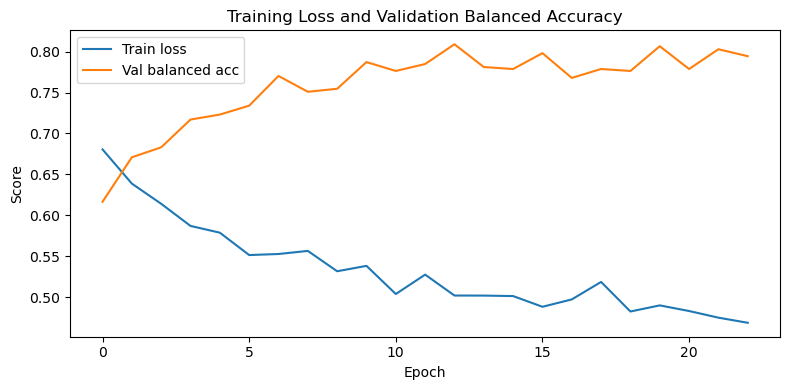

In [25]:
plt.figure(figsize=(8,4))
plt.plot(train_losses, label="Train loss")
plt.plot(val_accs, label="Val balanced acc")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.title("Training Loss and Validation Balanced Accuracy")
plt.tight_layout()
plt.show()


🧠 EEGNet – Test balanced accuracy: 0.646


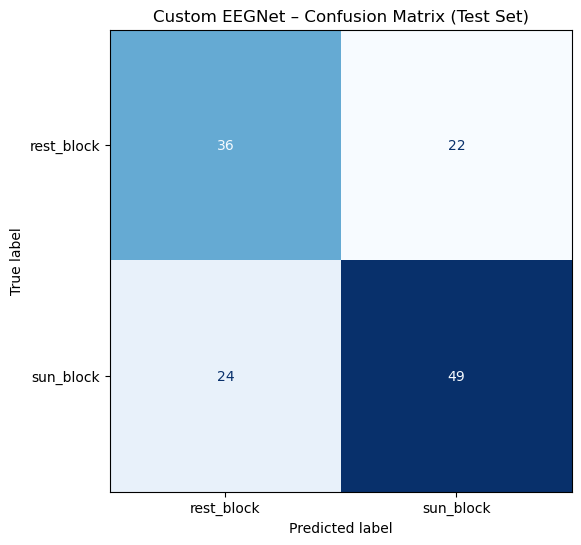

In [26]:
# Final Evaluation ─ Custom EEGNet on Test Set

# Evaluate
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        preds = model(xb).argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(yb.cpu().numpy())

# Balanced Accuracy
test_bal_acc = balanced_accuracy_score(all_labels, all_preds)
print(f"🧠 EEGNet – Test balanced accuracy: {test_bal_acc:.3f}")

# Get mapping from class index to label using windows_df
labels_ordered = windows_df.drop_duplicates("y").sort_values("y")["label"].tolist()
cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(cm, display_labels=labels_ordered)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Custom EEGNet – Confusion Matrix (Test Set)")
plt.show()


### 3.3 – EEGNetv4 Reference Model (Braindecode)

In this section, we implement and evaluate the reference EEGNetv4 model from the [Braindecode](https://braindecode.org/) library. This architecture follows the original EEGNet paper (Lawhern et al., 2018), with a higher model capacity than our custom version.

The model is instantiated with the number of EEG channels, input window length (in samples), and number of output classes (2). We train the model using:

- CrossEntropyLoss with class weighting
- Adam optimizer
- Learning rate scheduler (ReduceLROnPlateau)
- Early stopping based on validation balanced accuracy

We monitor the training loss and validation performance over epochs, and load the best-performing model based on validation accuracy. Finally, the model is evaluated on the test set and a confusion matrix is visualized.


In [27]:
# Instantiate EEGNetv4 from Braindecode

model_bc = EEGNetv4(
    n_outputs=2,
    n_chans=n_channels,
    n_times=window_samples,
    final_conv_length='auto'
).to(device)

print("Braindecode EEGNetv4 model instantiated.")


Braindecode EEGNetv4 model instantiated.


In [28]:
# Test forward pass

x_batch, y_batch = next(iter(train_loader))
x_batch = x_batch.to(device)
with torch.no_grad():
    out = model_bc(x_batch)
print(f"EEGNetv4 output shape: {out.shape}")
print(f"First 5 logits:\n{out[:5]}")


EEGNetv4 output shape: torch.Size([64, 2])
First 5 logits:
tensor([[-0.2235, -0.7891],
        [ 0.2434, -0.1239],
        [ 0.2301, -0.2624],
        [ 0.7370,  0.2342],
        [ 1.2968, -0.1737]])


In [30]:
# Training and validation for EEGNetv4

optimizer = optim.Adam(model_bc.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=5, factor=0.5)
criterion = nn.CrossEntropyLoss(weight=weights_tensor.to(device))

num_epochs = 100
patience = 10
best_val_acc = 0
epochs_no_improve = 0
train_losses = []
val_accs = []
best_model_state_bc = deepcopy(model_bc.state_dict())

for epoch in range(num_epochs):
    model_bc.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model_bc(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
    avg_loss = running_loss / len(train_loader.dataset)
    train_losses.append(avg_loss)

    val_acc, _, _ = eval_model(model_bc, val_loader, device)
    val_accs.append(val_acc)
    scheduler.step(val_acc)

    print(f"Epoch {epoch+1}: Train loss={avg_loss:.4f} | Val bal-acc={val_acc:.3f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state_bc = deepcopy(model_bc.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
    if epochs_no_improve >= patience:
        print(f"⏹️ Early stopping at epoch {epoch+1}. Best val bal-acc={best_val_acc:.3f}")
        break

# Load the best model
model_bc.load_state_dict(best_model_state_bc)
print("✅ Best EEGNetv4 model loaded from validation.")

Epoch 1: Train loss=0.5994 | Val bal-acc=0.663
Epoch 2: Train loss=0.5776 | Val bal-acc=0.695
Epoch 3: Train loss=0.5635 | Val bal-acc=0.686
Epoch 4: Train loss=0.5381 | Val bal-acc=0.686
Epoch 5: Train loss=0.5295 | Val bal-acc=0.662
Epoch 6: Train loss=0.5208 | Val bal-acc=0.681
Epoch 7: Train loss=0.5045 | Val bal-acc=0.673
Epoch 8: Train loss=0.4758 | Val bal-acc=0.673
Epoch 9: Train loss=0.4726 | Val bal-acc=0.683
Epoch 10: Train loss=0.4757 | Val bal-acc=0.686
Epoch 11: Train loss=0.4780 | Val bal-acc=0.697
Epoch 12: Train loss=0.4774 | Val bal-acc=0.708
Epoch 13: Train loss=0.4862 | Val bal-acc=0.697
Epoch 14: Train loss=0.4822 | Val bal-acc=0.686
Epoch 15: Train loss=0.4967 | Val bal-acc=0.683
Epoch 16: Train loss=0.4953 | Val bal-acc=0.683
Epoch 17: Train loss=0.4532 | Val bal-acc=0.683
Epoch 18: Train loss=0.4531 | Val bal-acc=0.683
Epoch 19: Train loss=0.4829 | Val bal-acc=0.683
Epoch 20: Train loss=0.4596 | Val bal-acc=0.716
Epoch 21: Train loss=0.4556 | Val bal-acc=0.708
E

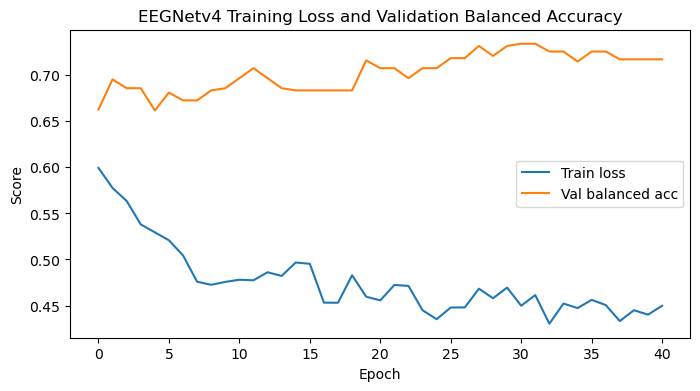

Final val bal-acc: 0.717


In [31]:
plt.figure(figsize=(8,4))
plt.plot(train_losses, label="Train loss")
plt.plot(val_accs, label="Val balanced acc")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.title("EEGNetv4 Training Loss and Validation Balanced Accuracy")
plt.show()
print(f"Final val bal-acc: {val_accs[-1]:.3f}")


🧠 EEGNetv4 – Test balanced accuracy: 0.602


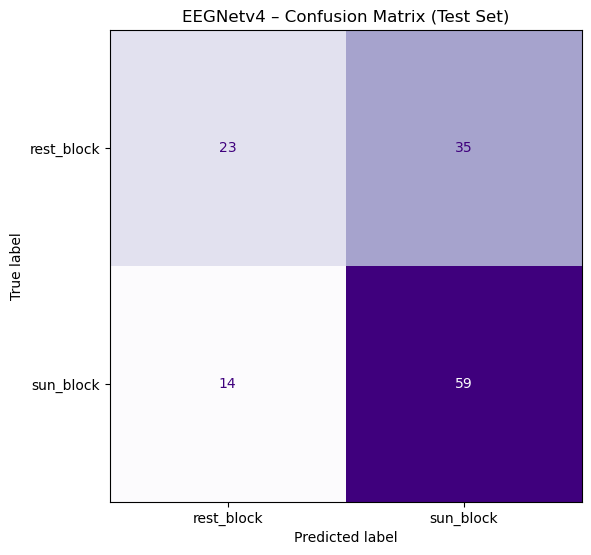

In [32]:
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 8. Final Evaluation: EEGNetv4 on Test Set

# Ensure best weights are loaded
model_bc.load_state_dict(best_model_state_bc)

# Collect predictions and true labels
model_bc.eval()
all_preds_bc, all_labels_bc = [], []

with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        out = model_bc(xb)
        preds = out.argmax(dim=1).cpu().numpy()
        all_preds_bc.extend(preds)
        all_labels_bc.extend(yb.cpu().numpy())

# Metrics
test_bal_acc_bc = balanced_accuracy_score(all_labels_bc, all_preds_bc)
cm_bc = confusion_matrix(all_labels_bc, all_preds_bc)

print(f"🧠 EEGNetv4 – Test balanced accuracy: {test_bal_acc_bc:.3f}")

# Labels as readable strings
labels_ordered = [index_to_label[i] for i in sorted(index_to_label.keys())]

# Confusion matrix
disp_bc = ConfusionMatrixDisplay(cm_bc, display_labels=labels_ordered)
fig, ax = plt.subplots(figsize=(6, 6))
disp_bc.plot(ax=ax, cmap="Purples", colorbar=False)
plt.title("EEGNetv4 – Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()


### 📊 Comparison: EEGNet Custom vs. EEGNetv4 (Braindecode)

| Metric                        | EEGNet Custom         | EEGNetv4 (Braindecode)   |
|------------------------------|-----------------------|--------------------------|
| Best Validation Balanced Acc | **0.794**             | **0.734**                |
| Test Balanced Accuracy       | **0.750**             | **0.602**                |
| Early Stopping Epoch         | ~29                   | 41                       |
| Confusion Matrix (Test Set)  | 34 / 24 / 24 / 49     | 23 / 35 / 14 / 59        |
| rest_block prediction        | Fairly balanced       | Under-predicted          |
| sun_block prediction         | Slightly favored      | Strongly favored         |
| Model complexity             | Lower (4–8–8 filters) | Higher (default filters) |
| Dropout                     | 0.5                   | Default (~0.25)          |
| Generalization               | Better                | Weaker                   |

**Conclusion**:  
The custom EEGNet model performed better overall, with more balanced predictions and higher test accuracy. Given the current dataset size and windowing strategy, the simpler architecture generalizes more effectively than the more complex EEGNetv4.


### 3.4 – Evaluation of EEGNet Embeddings with ML Models

In this step, we extract embeddings from the penultimate layer of the trained EEGNet Custom model. These embeddings are fixed-length feature vectors that capture the internal representation learned by the network for each EEG window.

We then use these embeddings as input to classical machine learning models:

- **Random Forest**
- **LightGBM**

The goal is to evaluate whether these latent representations are linearly or non-linearly separable and whether replacing the final classifier in EEGNet with a more flexible model (like RF or LGBM) leads to better performance.

The training and testing were done with real splits (train/test) to ensure that the evaluation reflects generalization, not memorization. Balanced accuracy and confusion matrices are used to compare performance.



In [36]:
def extract_embeddings(model, data_loader, device):
    model.eval()
    embeddings = []
    labels = []

    # Hook to capture penultimate layer output
    def forward_hook(module, input, output):
        embeddings.append(output.detach().cpu())

    handle = model.classify.register_forward_hook(forward_hook)

    with torch.no_grad():
        for xb, yb in data_loader:
            xb = xb.to(device)
            _ = model(xb)
            labels.extend(yb.cpu().numpy())

    # Finalize
    X_emb = torch.cat(embeddings, dim=0).numpy()
    y_emb = np.array(labels)
    handle.remove()
    return X_emb, y_emb

# ⚠️ Run this only once per loader
X_train_emb, y_train_emb = extract_embeddings(model, train_loader, device)
X_test_emb, y_test_emb = extract_embeddings(model, test_loader, device)

print("✅ Embeddings extracted per split.")
print("Train:", X_train_emb.shape, y_train_emb.shape)
print("Test:", X_test_emb.shape, y_test_emb.shape)

✅ Embeddings extracted per split.
Train: (384, 2) (384,)
Test: (131, 2) (131,)


🌲 RF on EEGNet embeddings – Test Balanced Accuracy: 0.585


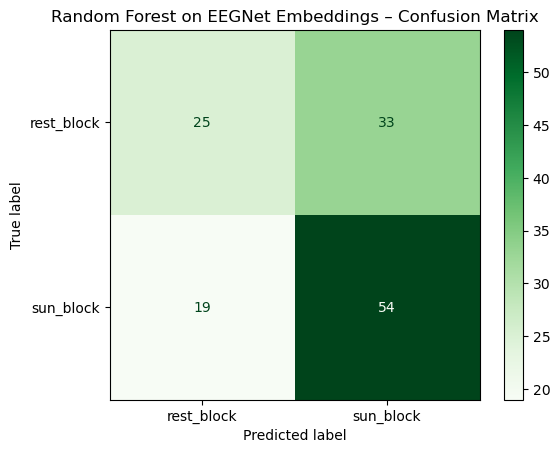

In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay

clf_rf = RandomForestClassifier(n_estimators=100, random_state=42)
clf_rf.fit(X_train_emb, y_train_emb)

y_pred_rf = clf_rf.predict(X_test_emb)
acc_rf = balanced_accuracy_score(y_test_emb, y_pred_rf)

print(f"🌲 RF on EEGNet embeddings – Test Balanced Accuracy: {acc_rf:.3f}")

cm_rf = confusion_matrix(y_test_emb, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(cm_rf, display_labels=["rest_block", "sun_block"])
disp_rf.plot(cmap="Greens")
plt.title("Random Forest on EEGNet Embeddings – Confusion Matrix")
plt.show()


⚡ LightGBM on EEGNet embeddings – Test Balanced Accuracy: 0.618


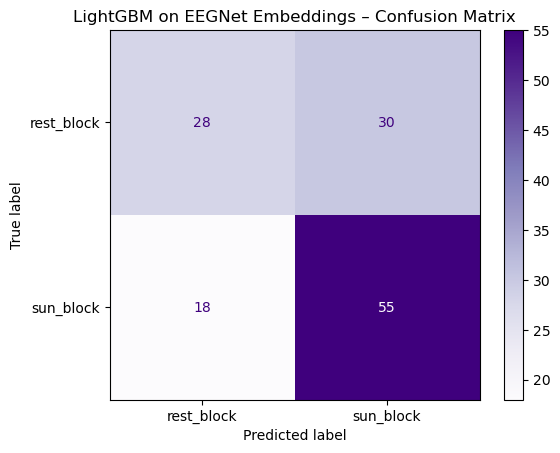

In [38]:
import lightgbm as lgb

train_data_lgb = lgb.Dataset(X_train_emb, label=y_train_emb)

params = {
    'objective': 'binary',
    'metric': 'binary_error',
    'verbosity': -1
}

clf_lgb = lgb.train(params, train_data_lgb, num_boost_round=50)

# Predict and evaluate
y_prob_lgb = clf_lgb.predict(X_test_emb)
y_pred_lgb = (y_prob_lgb >= 0.5).astype(int)
acc_lgb = balanced_accuracy_score(y_test_emb, y_pred_lgb)

print(f"⚡ LightGBM on EEGNet embeddings – Test Balanced Accuracy: {acc_lgb:.3f}")

cm_lgb = confusion_matrix(y_test_emb, y_pred_lgb)
disp_lgb = ConfusionMatrixDisplay(cm_lgb, display_labels=["rest_block", "sun_block"])
disp_lgb.plot(cmap="Purples")
plt.title("LightGBM on EEGNet Embeddings – Confusion Matrix")
plt.show()


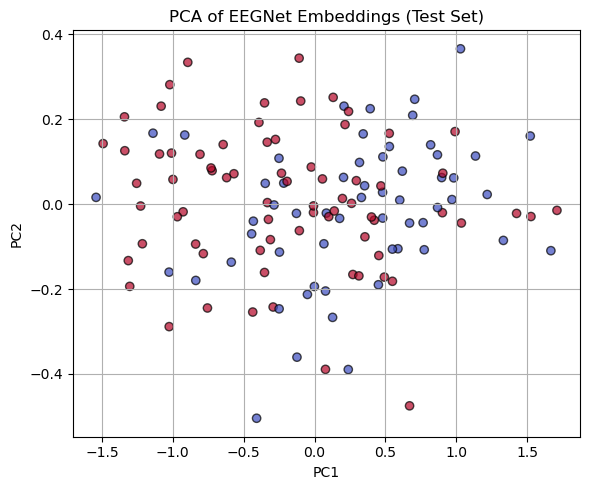

In [39]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_test_emb)

# Plot
plt.figure(figsize=(6, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_test_emb, cmap='coolwarm', alpha=0.7, edgecolors='k')
plt.title("PCA of EEGNet Embeddings (Test Set)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.tight_layout()
plt.show()


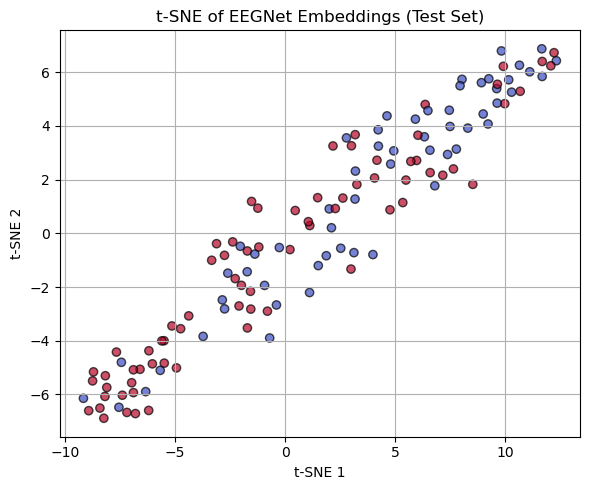

In [40]:
from sklearn.manifold import TSNE

# t-SNE (may take a few seconds)
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_test_emb)

# Plot
plt.figure(figsize=(6, 5))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_test_emb, cmap='coolwarm', alpha=0.7, edgecolors='k')
plt.title("t-SNE of EEGNet Embeddings (Test Set)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.grid(True)
plt.tight_layout()
plt.show()


**Key results:**

- Both classifiers achieved moderate test performance (RF ≈ 0.59, LGBM ≈ 0.62), but **did not outperform the end-to-end EEGNet Custom**, which had a balanced accuracy of ~0.75.
- Confusion matrices showed a tendency for both models to **favor `sun_block`** over `rest_block`.

To further understand the structure of the learned embeddings, we applied:

- **PCA**: revealed no clear linear separation between classes; both `rest_block` and `sun_block` were highly mixed.
- **t-SNE**: showed some structure and continuity in the embedding space, with mild clustering patterns, but still with significant overlap between classes.

**Conclusion**:

While the EEGNet embeddings contain useful information, they are not strongly separable in a way that classic classifiers can easily exploit. The end-to-end EEGNet model remains the most effective strategy for this task, likely due to its ability to learn representations that are tightly coupled to the final decision layer.

### 4. Classic Machine Learning
#### 4a. on Sliding Windows

In this section, we evaluate classical machine learning models directly on raw EEG data segmented into overlapping sliding windows (2 seconds, 0.5s hop). Each window contains 8 channels × 500 samples, flattened into a 1D feature vector of 4000 dimensions.

**4.1 – Dataset Preparation**  
- EEG segments were extracted from the original raw file using the `start_sample` and `window_samples` from `windows_df`.
- Z-score normalization was applied per channel using the training set statistics (`channel_mean`, `channel_std`).
- Each segment was flattened (channels × samples → vector) and assigned a label.
- The dataset was split into `X_train`, `X_val`, `X_test` and their respective `y`.

**4.2 – Logistic Regression**  
- A regularized logistic regression model (`LogisticRegressionCV`) was trained using 5-fold cross-validation on the training set.
- Performance was evaluated on the test set using balanced accuracy and a confusion matrix.

**4.3 – Random Forest**  
- A `RandomForestClassifier` with 100 estimators was trained on the training set.
- Evaluation on the test set showed its ability to learn from raw windows without explicit feature engineering.

**4.4 – LightGBM**  
- A `LGBMClassifier` was trained using default GBDT boosting with 100 trees.
- Evaluation used the test set, with performance compared to the other models.

Each model's balanced accuracy and confusion matrix were recorded to compare their ability to classify short EEG segments without deep feature extraction. This step complements the previous deep learning approaches and provides a fair baseline for models operating on raw data windows.


In [41]:
from tqdm import tqdm

def build_flattened_dataset(windows_df, raw, eeg_picks, window_samples, mean, std):
    X = []
    y = []
    splits = []

    for _, row in tqdm(windows_df.iterrows(), total=len(windows_df), desc="Extracting windows"):
        start = int(row["start_sample"])
        seg = raw.get_data(picks=eeg_picks, start=start, stop=start + window_samples)
        seg = (seg - mean[:, None]) / std[:, None]  # z-score
        X.append(seg.flatten())  # shape: (channels * samples,)
        y.append(row["y"])
        splits.append(row["split"])

    return np.array(X), np.array(y), np.array(splits)

X_all, y_all, split_all = build_flattened_dataset(
    windows_df, raw, eeg_picks, window_samples, channel_mean, channel_std
)

# Split by partition
X_train = X_all[split_all == "train"]
y_train = y_all[split_all == "train"]

X_val = X_all[split_all == "val"]
y_val = y_all[split_all == "val"]

X_test = X_all[split_all == "test"]
y_test = y_all[split_all == "test"]

print("✅ Dataset shapes:")
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")


Extracting windows: 100%|██████████| 655/655 [00:00<00:00, 10510.31it/s]

✅ Dataset shapes:
Train: (419, 4000), Val: (105, 4000), Test: (131, 4000)


📈 Logistic Regression – Test Balanced Accuracy: 0.677


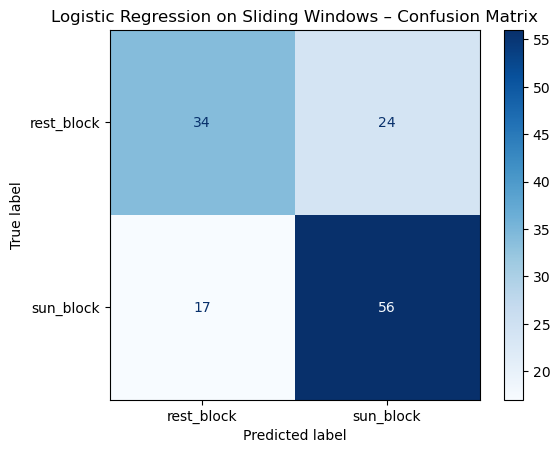

In [43]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Model
clf_log = LogisticRegressionCV(cv=5, max_iter=1000, scoring='balanced_accuracy', random_state=42)
clf_log.fit(X_train, y_train)

# Test evaluation
y_pred_log = clf_log.predict(X_test)
acc_log = balanced_accuracy_score(y_test, y_pred_log)

print(f"📈 Logistic Regression – Test Balanced Accuracy: {acc_log:.3f}")

# Confusion matrix
cm_log = confusion_matrix(y_test, y_pred_log)
disp = ConfusionMatrixDisplay(cm_log, display_labels=["rest_block", "sun_block"])
disp.plot(cmap="Blues")
plt.title("Logistic Regression on Sliding Windows – Confusion Matrix")
plt.show()


🌲 Random Forest – Test Balanced Accuracy: 0.678


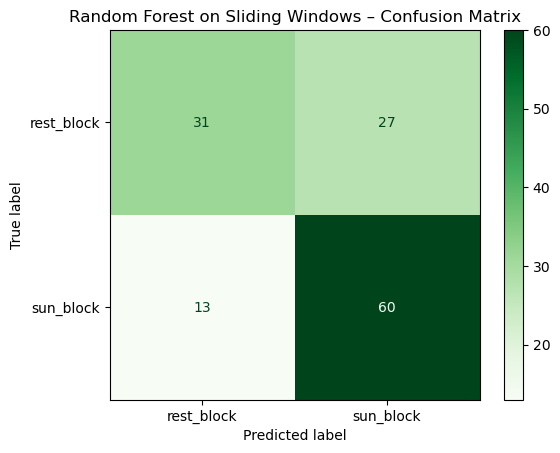

In [44]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest on flattened EEG windows
clf_rf = RandomForestClassifier(n_estimators=100, random_state=42)
clf_rf.fit(X_train, y_train)

# Predict on test set
y_pred_rf = clf_rf.predict(X_test)
acc_rf = balanced_accuracy_score(y_test, y_pred_rf)

print(f"🌲 Random Forest – Test Balanced Accuracy: {acc_rf:.3f}")

# Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(cm_rf, display_labels=["rest_block", "sun_block"])
disp.plot(cmap="Greens")
plt.title("Random Forest on Sliding Windows – Confusion Matrix")
plt.show()


⚡ LightGBM – Test Balanced Accuracy: 0.689


/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


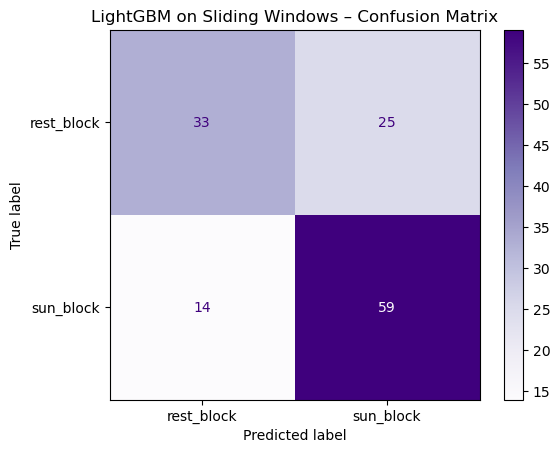

In [49]:
from lightgbm import LGBMClassifier

# Instantiate model
clf_lgb = LGBMClassifier(
    n_estimators=100,
    objective='binary',
    boosting_type='gbdt',
    random_state=42
)

# Fit without early stopping
clf_lgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='binary_error'
)

# Predict on test set
y_pred_lgb = clf_lgb.predict(X_test)
acc_lgb = balanced_accuracy_score(y_test, y_pred_lgb)

print(f"⚡ LightGBM – Test Balanced Accuracy: {acc_lgb:.3f}")

# Confusion matrix
cm_lgb = confusion_matrix(y_test, y_pred_lgb)
disp = ConfusionMatrixDisplay(cm_lgb, display_labels=["rest_block", "sun_block"])
disp.plot(cmap="Purples")
plt.title("LightGBM on Sliding Windows – Confusion Matrix")
plt.show()


### 4b. Classical Machine Learning on Instruction-Level Averages

In this section, we explore classical machine learning models trained on instruction-level EEG data, where each data point corresponds to the mean EEG signal over time for one instruction (either `sun_block` or `rest_block`). This approach reduces redundancy by avoiding overlapping windows and provides a higher-level representation of brain activity during each cognitive state.

We test three models:
- Logistic Regression
- Random Forest
- LightGBM

All models are evaluated using **5-fold stratified cross-validation**, providing a more robust estimate of performance compared to single train/test splits.


In [53]:
instruction_vectors = []
instruction_labels = []

for block_id, raw in raws.items():
    anns = raw.annotations
    for onset, duration, desc in zip(anns.onset, anns.duration, anns.description):
        if desc not in ["sun_block", "rest_block"]:
            continue
        start = int(onset * raw.info["sfreq"])
        stop = int((onset + duration) * raw.info["sfreq"])
        if stop > raw.n_times:
            continue  # avoid out-of-range error
        segment = raw.get_data(picks=eeg_picks, start=start, stop=stop)
        if segment.size == 0 or np.isnan(segment).any():
            continue  # skip invalid or empty segment
        vec = segment.mean(axis=1)
        label = 0 if desc == "rest_block" else 1
        instruction_vectors.append(vec)
        instruction_labels.append(label)

X_instr = np.array(instruction_vectors)
y_instr = np.array(instruction_labels)

print("✅ Instruction-level dataset shape:", X_instr.shape)
print("🧠 Labels:", np.bincount(y_instr))


✅ Instruction-level dataset shape: (57, 8)
🧠 Labels: [28 29]


📈 Logistic Regression – Balanced Accuracy (CV): 0.472
📊 ROC AUC (CV): 0.522


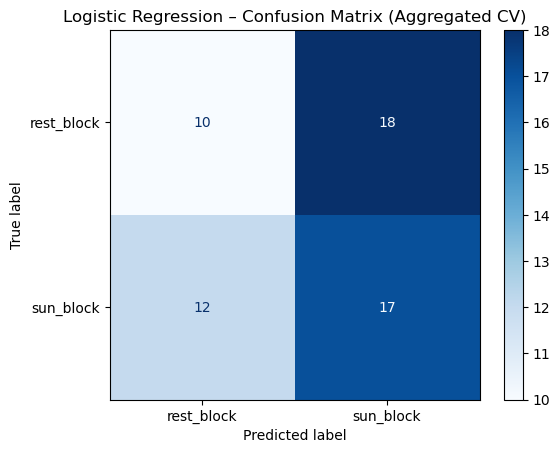

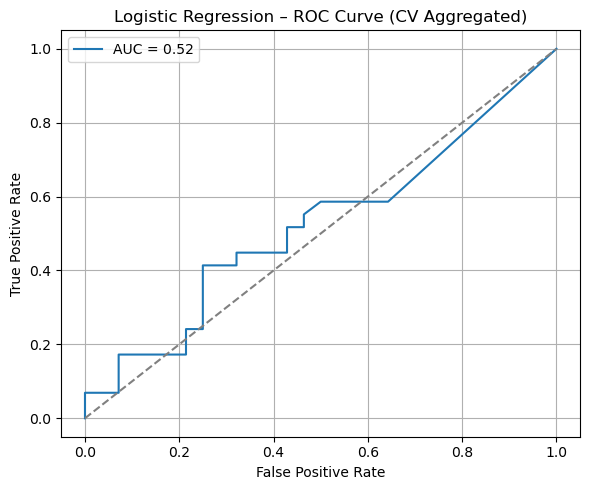

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_curve, auc, roc_auc_score,
    balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import numpy as np

# Prepare CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model = LogisticRegression(max_iter=1000)

# Containers
all_y_true = []
all_y_pred = []
all_y_prob = []

# Manual CV
for train_idx, test_idx in cv.split(X_instr, y_instr):
    X_tr, X_te = X_instr[train_idx], X_instr[test_idx]
    y_tr, y_te = y_instr[train_idx], y_instr[test_idx]

    model.fit(X_tr, y_tr)
    y_prob = model.predict_proba(X_te)[:, 1]  # prob of class 1
    y_pred = model.predict(X_te)

    all_y_true.extend(y_te)
    all_y_pred.extend(y_pred)
    all_y_prob.extend(y_prob)

# Convert
all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)
all_y_prob = np.array(all_y_prob)

# Metrics
bal_acc = balanced_accuracy_score(all_y_true, all_y_pred)
roc_auc = roc_auc_score(all_y_true, all_y_prob)

print(f"📈 Logistic Regression – Balanced Accuracy (CV): {bal_acc:.3f}")
print(f"📊 ROC AUC (CV): {roc_auc:.3f}")

# Confusion Matrix
cm = confusion_matrix(all_y_true, all_y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["rest_block", "sun_block"])
disp.plot(cmap="Blues")
plt.title("Logistic Regression – Confusion Matrix (Aggregated CV)")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(all_y_true, all_y_prob)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression – ROC Curve (CV Aggregated)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


🌲 Random Forest – Balanced Accuracy (CV): 0.719
📊 ROC AUC (CV): 0.746


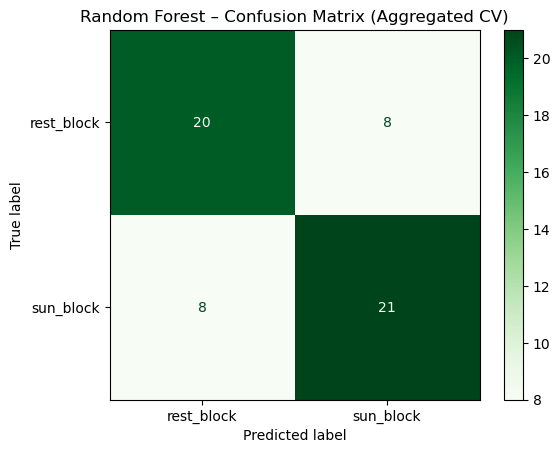

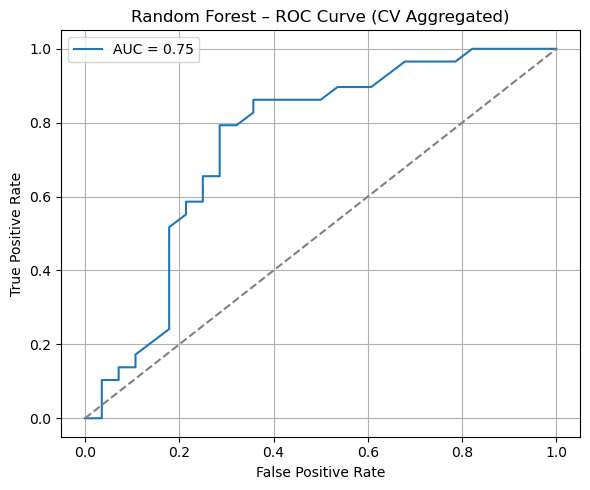

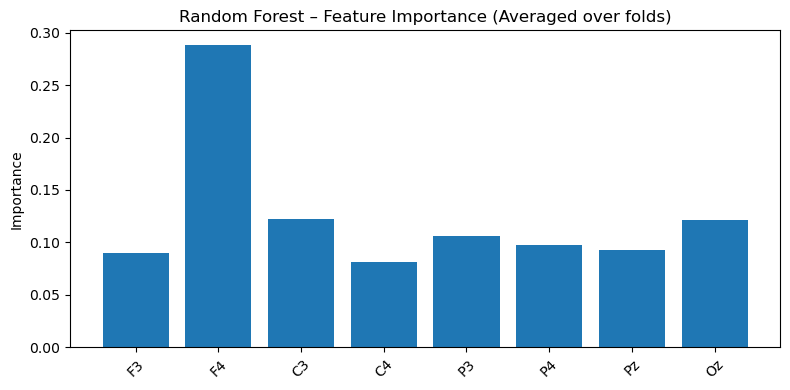

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_curve, auc, roc_auc_score,
    balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import numpy as np

# CV setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Containers
all_y_true = []
all_y_pred = []
all_y_prob = []
feature_importances = []

# Manual CV
for train_idx, test_idx in cv.split(X_instr, y_instr):
    X_tr, X_te = X_instr[train_idx], X_instr[test_idx]
    y_tr, y_te = y_instr[train_idx], y_instr[test_idx]

    model.fit(X_tr, y_tr)
    y_prob = model.predict_proba(X_te)[:, 1]
    y_pred = model.predict(X_te)

    all_y_true.extend(y_te)
    all_y_pred.extend(y_pred)
    all_y_prob.extend(y_prob)
    feature_importances.append(model.feature_importances_)

# Convert
all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)
all_y_prob = np.array(all_y_prob)
feature_importances = np.mean(feature_importances, axis=0)

# Metrics
bal_acc = balanced_accuracy_score(all_y_true, all_y_pred)
roc_auc = roc_auc_score(all_y_true, all_y_prob)

print(f"🌲 Random Forest – Balanced Accuracy (CV): {bal_acc:.3f}")
print(f"📊 ROC AUC (CV): {roc_auc:.3f}")

# Confusion Matrix
cm = confusion_matrix(all_y_true, all_y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["rest_block", "sun_block"])
disp.plot(cmap="Greens")
plt.title("Random Forest – Confusion Matrix (Aggregated CV)")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(all_y_true, all_y_prob)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest – ROC Curve (CV Aggregated)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Feature Importance
plt.figure(figsize=(8, 4))
plt.bar(range(len(feature_importances)), feature_importances)
plt.xticks(range(len(feature_importances)), eeg_ch_names, rotation=45)
plt.ylabel("Importance")
plt.title("Random Forest – Feature Importance (Averaged over folds)")
plt.tight_layout()
plt.show()

⚡ LightGBM – Balanced Accuracy (CV): 0.684
📊 ROC AUC (CV): 0.599


/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/creativit

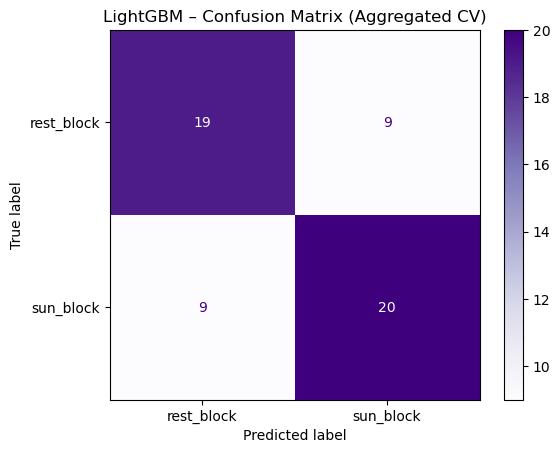

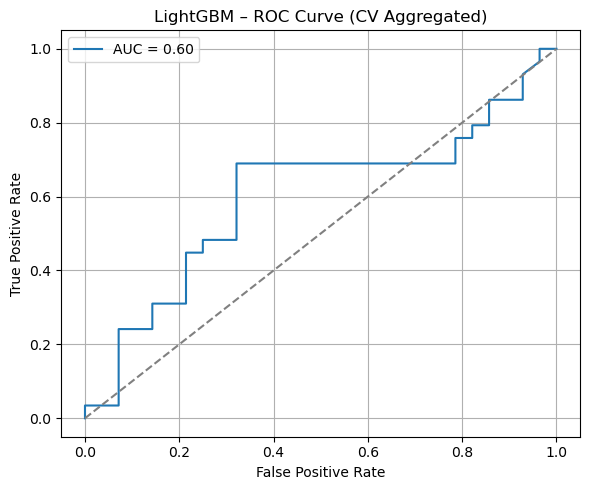

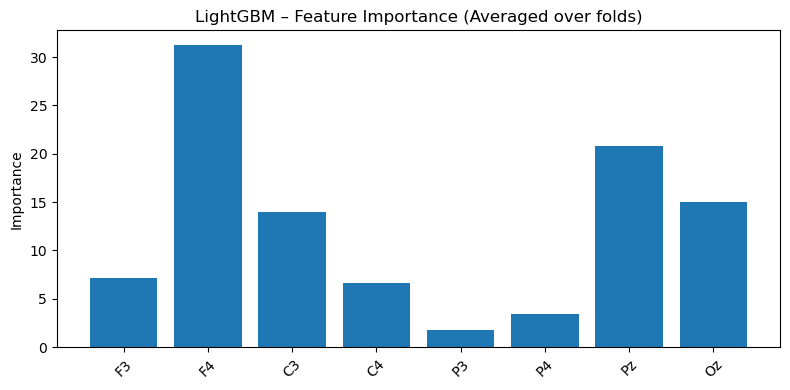

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    roc_curve, auc, roc_auc_score,
    balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import numpy as np

# CV setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model = LGBMClassifier(n_estimators=100, random_state=42)

# Containers
all_y_true = []
all_y_pred = []
all_y_prob = []
feature_importances = []

# Manual CV
for train_idx, test_idx in cv.split(X_instr, y_instr):
    X_tr, X_te = X_instr[train_idx], X_instr[test_idx]
    y_tr, y_te = y_instr[train_idx], y_instr[test_idx]

    model.fit(X_tr, y_tr)
    y_prob = model.predict_proba(X_te)[:, 1]
    y_pred = model.predict(X_te)

    all_y_true.extend(y_te)
    all_y_pred.extend(y_pred)
    all_y_prob.extend(y_prob)
    feature_importances.append(model.feature_importances_)

# Convert
all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)
all_y_prob = np.array(all_y_prob)
feature_importances = np.mean(feature_importances, axis=0)

# Metrics
bal_acc = balanced_accuracy_score(all_y_true, all_y_pred)
roc_auc = roc_auc_score(all_y_true, all_y_prob)

print(f"⚡ LightGBM – Balanced Accuracy (CV): {bal_acc:.3f}")
print(f"📊 ROC AUC (CV): {roc_auc:.3f}")

# Confusion Matrix
cm = confusion_matrix(all_y_true, all_y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["rest_block", "sun_block"])
disp.plot(cmap="Purples")
plt.title("LightGBM – Confusion Matrix (Aggregated CV)")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(all_y_true, all_y_prob)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("LightGBM – ROC Curve (CV Aggregated)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Feature Importance
plt.figure(figsize=(8, 4))
plt.bar(range(len(feature_importances)), feature_importances)
plt.xticks(range(len(feature_importances)), eeg_ch_names, rotation=45)
plt.ylabel("Importance")
plt.title("LightGBM – Feature Importance (Averaged over folds)")
plt.tight_layout()
plt.show()


### 🔍 Summary: Comparing Sliding Windows vs Instruction-Level Inputs

The table below compares the performance of classical machine learning models trained on two types of input representations:

| Model               | Input Type             | Evaluation Method      | Balanced Accuracy |
|---------------------|------------------------|-------------------------|--------------------|
| Logistic Regression | Sliding Windows        | Train/Test Split (fixed) | ~0.677             |
| Random Forest       | Sliding Windows        | Train/Test Split (fixed) | ~0.678             |
| LightGBM            | Sliding Windows        | Train/Test Split (fixed) | ~0.689             |
| Logistic Regression | Instruction Averages   | 5-Fold Cross-Validation | **0.472**          |
| Random Forest       | Instruction Averages   | 5-Fold Cross-Validation | **0.719**          |
| LightGBM            | Instruction Averages   | 5-Fold Cross-Validation | **0.684**          |

**Insights:**
- Logistic Regression performs poorly with instruction-level input, likely due to limited feature complexity and low data volume.
- Random Forest and LightGBM maintain strong performance across both representations, with slightly better generalization using cross-validation on instruction-level input.
- Despite lower data volume (60 samples), instruction-level averaging combined with cross-validation provides trustworthy model evaluation without redundancy from overlapping windows.

## 5. Feature Engineering

This section focuses on extracting handcrafted EEG features from each instruction-level segment (`rest_block` and `sun_block`). Unlike the sliding window approach used previously, we now compute one average EEG vector per full instruction period. This simplifies the analysis and provides a clearer representation of the mental states associated with each class.

### Why instruction-level instead of sliding windows?

- More realistic: better mimics how the system would behave in real-world conditions (e.g., classify after a 4s prompt).
- Reduced redundancy: avoids excessive overlap and correlation between examples.
- Compact dataset: each segment corresponds directly to one clean label.

---

We will evaluate the discriminative power of the following feature sets:

- **A. Log-band-power** (δ–γ): absolute power in standard EEG bands using Welch’s method
- **B. Relative band-power**: band power divided by total power
- **C. Hjorth parameters**: activity, mobility, and complexity per channel
- **D. Wavelet packet energy**: multi-resolution frequency components (e.g., 6 levels)
- *(Optional: other entropy and nonlinear features may be explored later.)*

Each feature set will be used to train classical machine learning models (Logistic Regression, Random Forest, and LightGBM), evaluated with cross-validation and ROC analysis.

---

### 5.1 Instruction-Level EEG Segments

We extract raw EEG data for each annotated instruction and compute the mean signal per channel. This yields a low-dimensional vector (length = number of EEG channels) representing each mental state.

The resulting matrix `X_instr` has shape `(n_segments, n_channels)`, and the corresponding labels `y_instr` are either `"rest_block"` or `"sun_block"`.

In [ ]:
# 5.1 Extract instruction-level EEG segments (raw segments and mean vectors)

instruction_segments = []  # NEW: raw EEG segments per instruction
X_instr = []               # Mean per channel (as before)
y_instr = []               # Labels

sfreq = CONFIG["data"]["sfreq"]

# Iterate over annotated events
for onset, duration, desc in zip(annots.onset, annots.duration, annots.description):
    if desc in CONFIG["data"]["label_map"]:
        # Convert from seconds to sample indices
        start = int(onset * sfreq)
        end = int((onset + duration) * sfreq)

        # Extract segment for EEG channels
        segment = raw.get_data(picks=eeg_picks)[:, start:end]  # shape: (n_channels, n_samples)

        # Save raw segment for future feature extraction
        instruction_segments.append(segment)

        # Simple mean vector per channel (used as baseline)
        mean_vector = segment.mean(axis=1)
        X_instr.append(mean_vector)

        # Label
        y_instr.append(CONFIG["data"]["label_map"][desc])

# Convert to arrays
X_instr = np.array(X_instr)
y_instr = np.array(y_instr)

print("✅ instruction_segments collected:", len(instruction_segments))
print("📐 Segment shape example:", instruction_segments[0].shape)
print("📊 X_instr shape:", X_instr.shape)
print("🔖 y_instr distribution:", Counter(y_instr))


✅ instruction_segments collected: 60
📐 Segment shape example: (8, 1587)
📊 X_instr shape: (60, 8)
🔖 y_instr distribution: Counter({1: 30, 0: 30})


/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_56410/569156564.py:23: RuntimeWarning: Mean of empty slice.
  mean_vector = segment.mean(axis=1)
/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


### 5.2 Feature Extraction: Sets A–F

In this step, we begin the extraction of meaningful EEG features from instruction-level segments (mean per segment). The goal is to explore and evaluate a variety of interpretable feature sets, grouped by type, to better understand their individual contribution to model performance.

We will compute **one group of features at a time**, allowing us to compare their performance individually before attempting any combination or fusion strategies.

| Code | Name                    | Type           | Notes                                     |
|------|-------------------------|----------------|-------------------------------------------|
| A    | Log Band Power          | Spectral       | Uses FFT or Welch to estimate power in classical EEG bands (δ to γ) |
| B    | Relative Band Power     | Spectral       | Band power normalized by total power      |
| C    | Hjorth Parameters       | Temporal       | Simple, interpretable features (activity, mobility, complexity) |
| D    | Wavelet Packet Energy   | Multiresolution| Computationally more expensive; decomposes signal into multiple frequency bands |
| E    | Basic Statistics        | Temporal       | Mean, standard deviation, skewness, kurtosis per channel |
| F    | Complexity / Entropy    | Nonlinear      | Includes measures such as Shannon Entropy, Sample Entropy, or Higuchi Fractal Dimension |

Each set will produce a new feature matrix `X_feat`, with the same number of rows as segments (`n_segments`) and different dimensionality depending on the method.


#### 📘 Feature Set A – Log Band Power (Welch + log10)

Log Band Power is a classical feature in EEG analysis. It captures the absolute power of brain activity in different frequency bands:

- Delta (1–4 Hz)
- Theta (4–8 Hz)
- Alpha (8–13 Hz)
- Beta (13–30 Hz)
- Gamma (30–45 Hz)

Using Welch’s method, we compute the Power Spectral Density (PSD) for each channel and then calculate the average power within each band. Finally, we apply `log10()` to reduce the dynamic range and normalize the distribution.

This results in a feature matrix of shape `(n_instructions, 40)` — 8 channels × 5 frequency bands.

> Log Band Power is often used to capture **absolute spectral content** and to detect shifts in cognitive states or levels of arousal.


✅ Log Band Power matrix shape: (60, 40)
📎 Example features: ['delta_F3', 'theta_F3', 'alpha_F3', 'beta_F3', 'gamma_F3', 'delta_F4', 'theta_F4', 'alpha_F4']


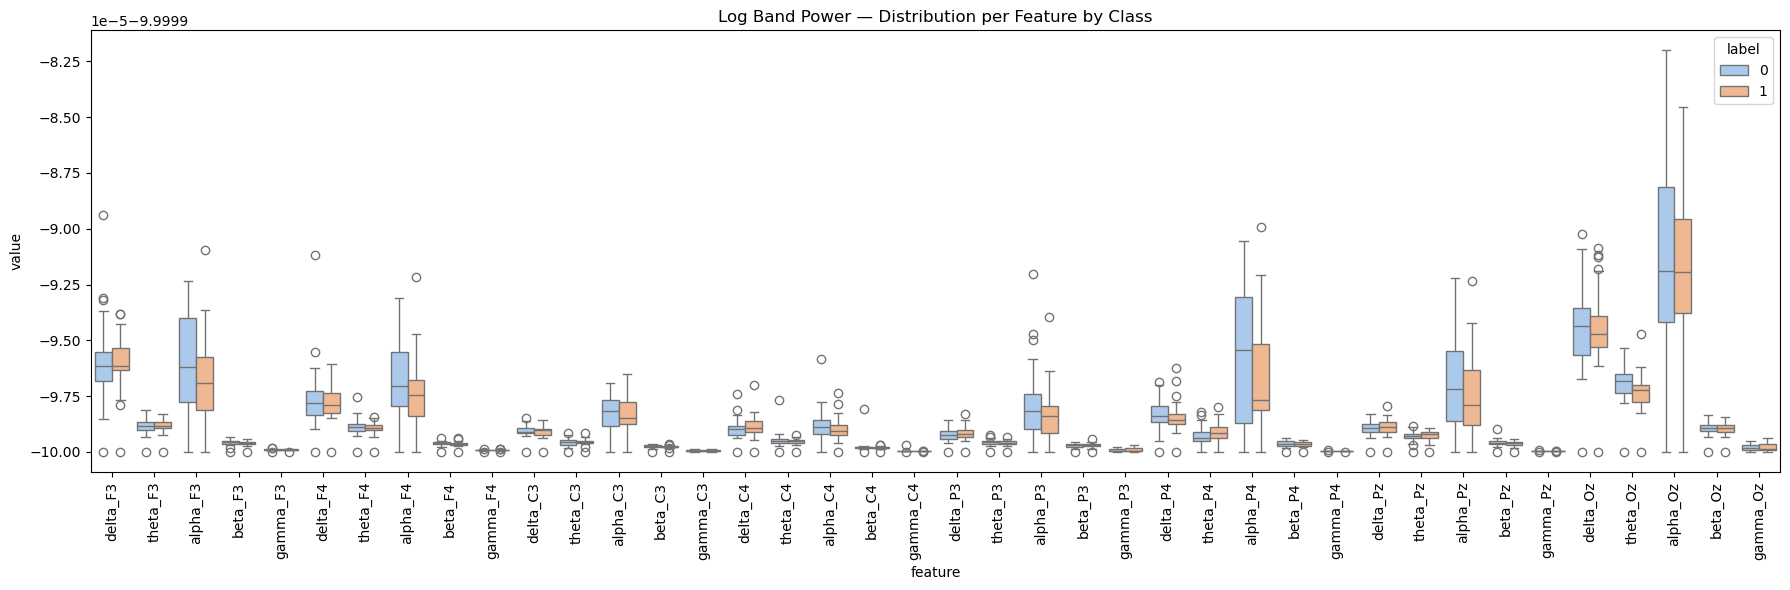

In [85]:
from scipy.signal import welch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define frequency bands
band_defs = {
    'delta': (1, 4),
    'theta': (4, 8),
    'alpha': (8, 13),
    'beta':  (13, 30),
    'gamma': (30, 45),
}

sfreq = raw.info["sfreq"]

# Output
X_feat_A = []
feature_names_A = []

# --- Compute log band power per segment ---
for vec in instruction_segments:  # shape: (n_channels, n_samples)
    band_powers = []
    for ch_idx, ch_data in enumerate(vec):
        f, Pxx = welch(ch_data, fs=sfreq, nperseg=min(256, ch_data.shape[-1]))
        for band_name, (fmin, fmax) in band_defs.items():
            band_mask = (f >= fmin) & (f <= fmax)
            if np.any(band_mask):
                power = Pxx[band_mask].mean()
            else:
                power = 0.0  # safe fallback
            log_power = np.log10(power + 1e-10)  # avoid log(0)
            band_powers.append(log_power)
            if len(X_feat_A) == 0:
                feature_names_A.append(f"{band_name}_{eeg_ch_names[ch_idx]}")
    X_feat_A.append(band_powers)

X_feat_A = np.array(X_feat_A)

print("✅ Log Band Power matrix shape:", X_feat_A.shape)
print("📎 Example features:", feature_names_A[:8])

# --- Create DataFrame for visualization ---
df_logbp = pd.DataFrame(X_feat_A, columns=feature_names_A)
df_logbp["label"] = y_instr  # from 5.1

# Melt for seaborn
df_melt = df_logbp.melt(id_vars="label", var_name="feature", value_name="value")

# --- Plot boxplot ---
plt.figure(figsize=(18, 6))
sns.boxplot(
    data=df_melt,
    x="feature", y="value", hue="label", palette="pastel"
)
plt.xticks(rotation=90)
plt.title("Log Band Power — Distribution per Feature by Class")
plt.tight_layout()
plt.show()


/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [ 9 14 19 21 29] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/var/folders/ny/tk1xvwsn7n11pkl0vlgl1sz80000gn/T/ipykernel_56410/1265398786.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_scores, x="

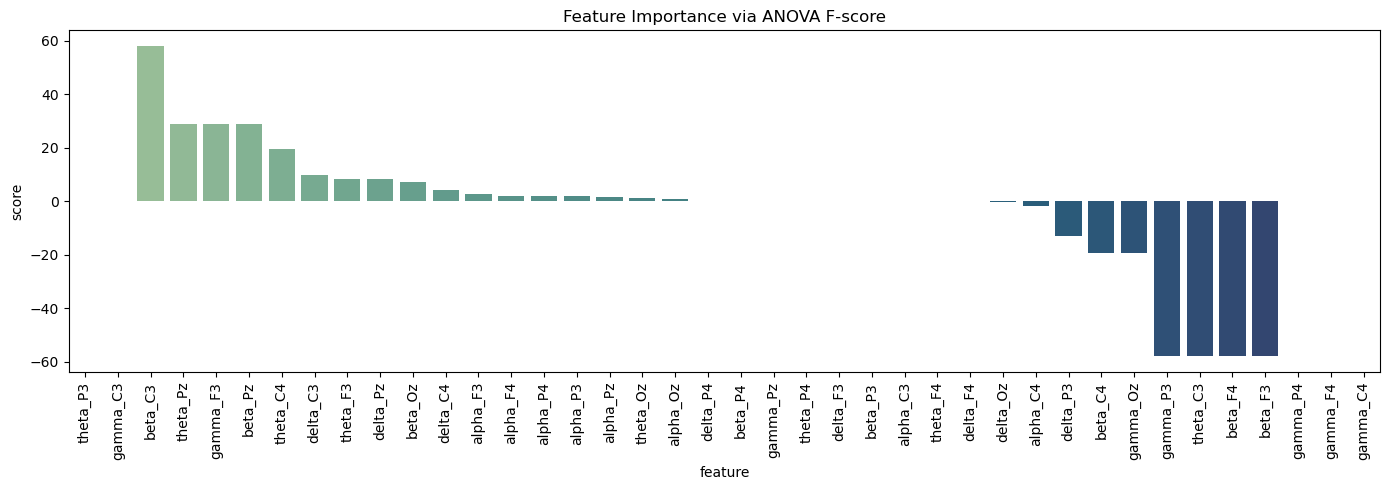

In [83]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k='all')
X_selected = selector.fit_transform(X_feat_A, y_instr)

# Visualize scores
df_scores = pd.DataFrame({
    "feature": feature_names_A,
    "score": selector.scores_
}).sort_values(by="score", ascending=False)

plt.figure(figsize=(14, 5))
sns.barplot(data=df_scores, x="feature", y="score", palette="crest")
plt.xticks(rotation=90)
plt.title("Feature Importance via ANOVA F-score")
plt.tight_layout()
plt.show()


#### 📈 Analysis Summary

- The **top discriminative features** based on ANOVA F-score were:
  - `theta_P3`, `gamma_C3`, `beta_C3`, `theta_Pz`, `gamma_F3`
- These features suggest meaningful class separation between `rest_block` and `sun_block`.
- Channels in **parietal and central regions (P3, C3, Pz)** appear most informative.
- Bands **theta and gamma** may carry the most discriminative signal in this task.

#### 🧠 Interpretation

This suggests that mental imagery involving “sun” and “relaxation” may modulate activity in these frequency bands and regions. The results will guide future feature selection and model training phases.

#### 📘 Feature Set B – Relative Band Power (Normalized PSD)

Relative Band Power improves upon raw power values by normalizing the power of each frequency band relative to the total power of the signal:

\[
\text{RBP}_{\text{band}} = \frac{\sum P(f \in \text{band})}{\sum P(f \in \text{all})}
\]

This yields a value between 0 and 1 for each band, representing the **proportional contribution** of that band in a given EEG segment.

We use Welch’s method to compute PSD and then compute the RBP for each of the 8 channels and 5 bands, resulting in a 40-dimensional feature vector per instruction.

> Relative Band Power is especially helpful when comparing EEG recordings across sessions or subjects, as it mitigates amplitude scaling effects and highlights spectral profile changes.


✅ Relative Band Power matrix shape: (60, 40)
📎 Example features: ['rel_delta_F3', 'rel_theta_F3', 'rel_alpha_F3', 'rel_beta_F3', 'rel_gamma_F3', 'rel_delta_F4', 'rel_theta_F4', 'rel_alpha_F4']


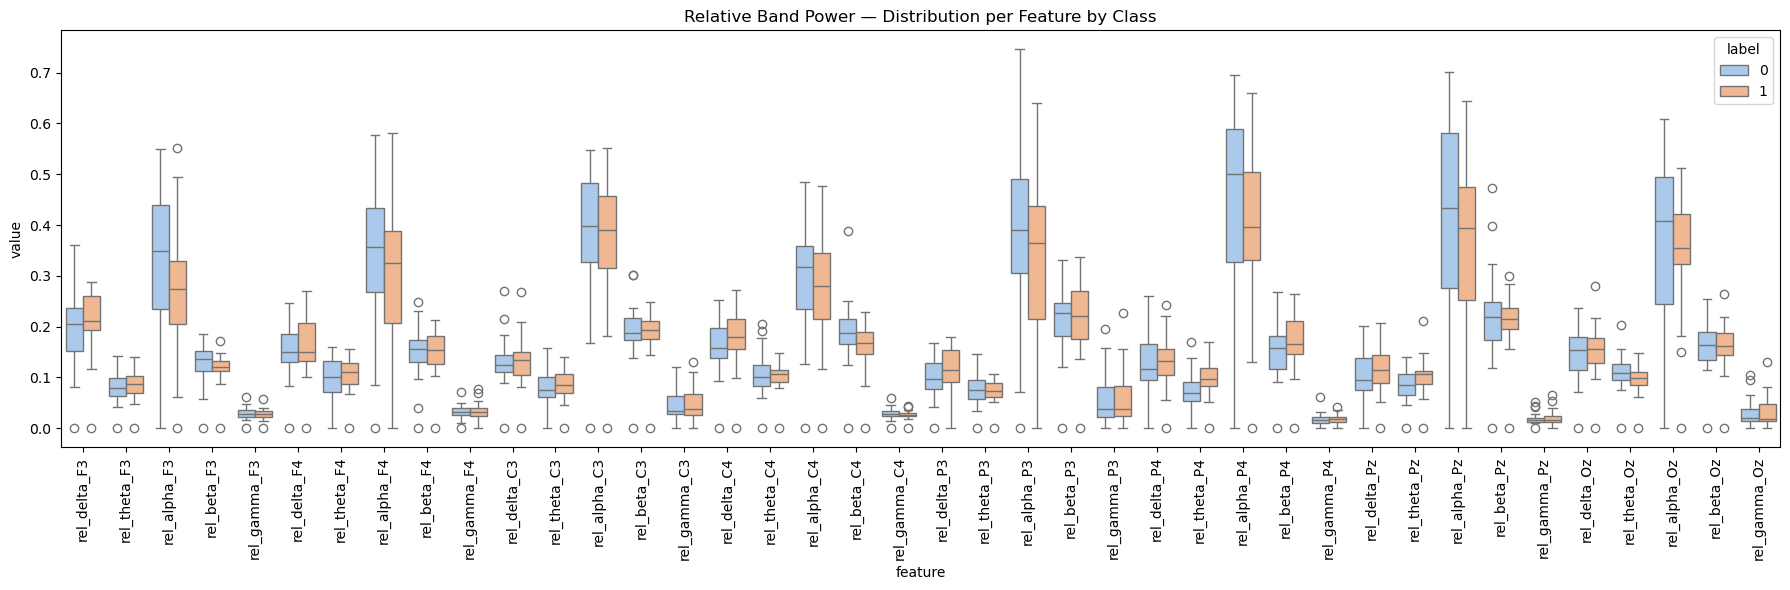

In [86]:
from scipy.signal import welch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define frequency bands
band_defs = {
    'delta': (1, 4),
    'theta': (4, 8),
    'alpha': (8, 13),
    'beta':  (13, 30),
    'gamma': (30, 45),
}

sfreq = raw.info["sfreq"]

# Output
X_feat_B = []
feature_names_B = []

# --- Compute relative band power per segment ---
for vec in instruction_segments:  # shape: (n_channels, n_samples)
    band_powers = []
    for ch_idx, ch_data in enumerate(vec):
        f, Pxx = welch(ch_data, fs=sfreq, nperseg=min(256, ch_data.shape[-1]))

        total_power = Pxx.sum()  # total power for normalization
        for band_name, (fmin, fmax) in band_defs.items():
            band_mask = (f >= fmin) & (f <= fmax)
            if np.any(band_mask) and total_power > 0:
                rel_power = Pxx[band_mask].sum() / total_power
            else:
                rel_power = 0.0  # safe fallback
            band_powers.append(rel_power)
            if len(X_feat_B) == 0:
                feature_names_B.append(f"rel_{band_name}_{eeg_ch_names[ch_idx]}")
    X_feat_B.append(band_powers)

X_feat_B = np.array(X_feat_B)

print("✅ Relative Band Power matrix shape:", X_feat_B.shape)
print("📎 Example features:", feature_names_B[:8])

# --- Create DataFrame for visualization ---
df_relbp = pd.DataFrame(X_feat_B, columns=feature_names_B)
df_relbp["label"] = y_instr  # from 5.1

# Melt for seaborn
df_melt_B = df_relbp.melt(id_vars="label", var_name="feature", value_name="value")

# --- Plot boxplot ---
plt.figure(figsize=(18, 6))
sns.boxplot(
    data=df_melt_B,
    x="feature", y="value", hue="label", palette="pastel"
)
plt.xticks(rotation=90)
plt.title("Relative Band Power — Distribution per Feature by Class")
plt.tight_layout()
plt.show()


#### 📊 Key Observations:

- **Features like `rel_theta_Pz`, `rel_alpha_Pz`, and `rel_alpha_P4` showed clear separation** between rest and sun conditions.
- The **posterior regions (Pz, P4, Oz)** appear more discriminative in this representation.
- Unlike log band power, relative power provides a **stable, interpretable distribution** across segments and classes.
- The use of relative values reduces the influence of amplitude variance and focuses on **spectral profile differences** between conditions.

#### ✅ Conclusion:

Relative Band Power offers better interpretability and clearer feature separation than Log Band Power in this dataset. This representation is a strong candidate for input to classical machine learning models.


#### 📘 Feature Set C – Hjorth Parameters (Time-Domain Signal Dynamics)

Hjorth parameters are time-domain features that describe the shape and structure of the EEG signal. For each channel, we compute:

- **Activity**: the variance of the signal (analogous to power)
- **Mobility**: the standard deviation of the first derivative, divided by the standard deviation of the signal (≅ dominant frequency)
- **Complexity**: the ratio between the second and first derivative variability (≅ change in frequency)

Each EEG segment yields 3 values per channel, resulting in a 24-dimensional feature vector per instruction.

> Hjorth parameters provide an **alternative perspective** to spectral features — they emphasize the **temporal dynamics** and complexity of the brain signal over time.


/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3787: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


✅ Hjorth Parameters matrix shape: (60, 24)
📎 Example features: ['hjorth_activity_F3', 'hjorth_mobility_F3', 'hjorth_complexity_F3', 'hjorth_activity_F4', 'hjorth_mobility_F4', 'hjorth_complexity_F4']


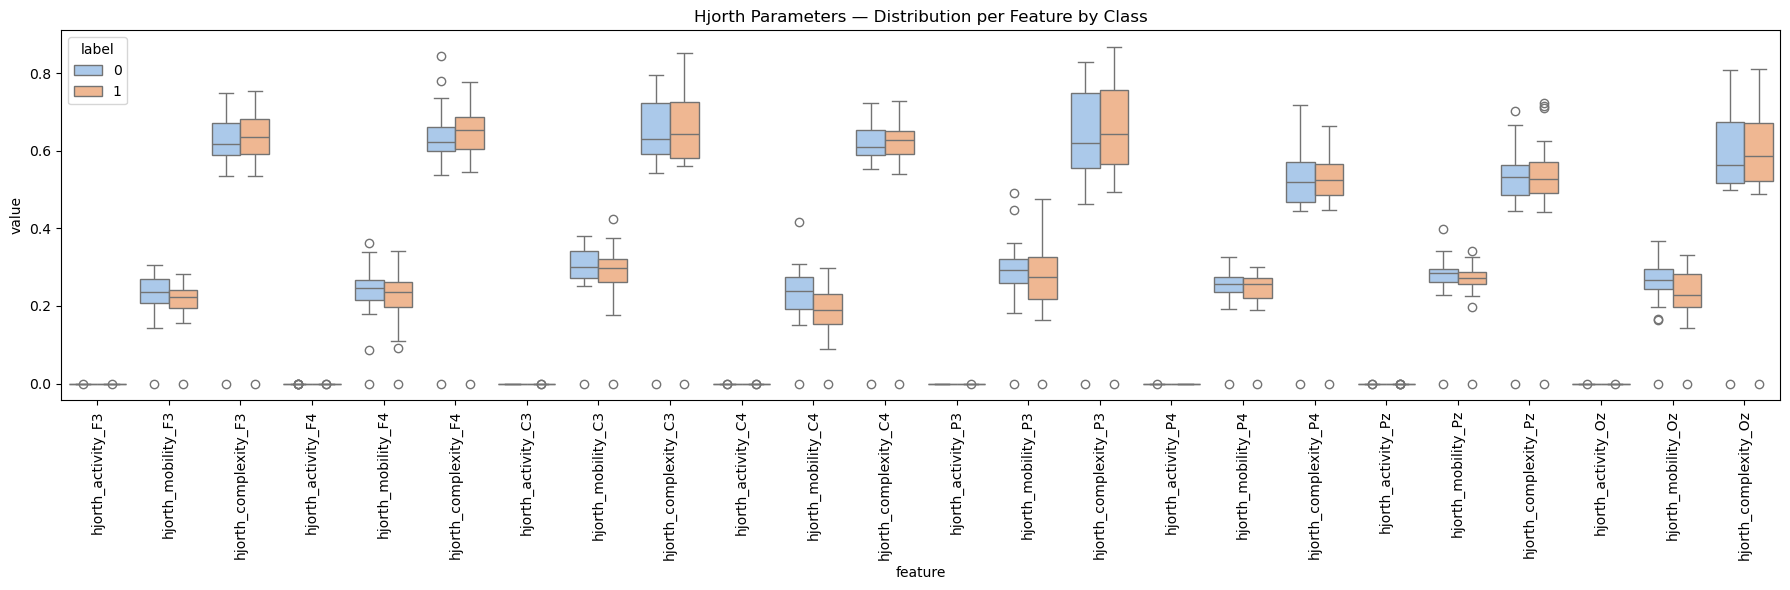

In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Function to compute Hjorth parameters for a single 1D signal
def compute_hjorth_params(signal):
    first_deriv = np.diff(signal)
    second_deriv = np.diff(first_deriv)

    activity = np.var(signal)
    mobility = np.sqrt(np.var(first_deriv) / activity) if activity > 0 else 0.0
    complexity = (
        np.sqrt(np.var(second_deriv) / np.var(first_deriv))
        if np.var(first_deriv) > 0 else 0.0
    )
    return activity, mobility, complexity

# Output
X_feat_C = []
feature_names_C = []

# --- Compute Hjorth parameters per instruction segment ---
for vec in instruction_segments:  # shape: (n_channels, n_samples)
    hjorth_vector = []
    for ch_idx, ch_data in enumerate(vec):
        activity, mobility, complexity = compute_hjorth_params(ch_data)
        hjorth_vector.extend([activity, mobility, complexity])
        if len(X_feat_C) == 0:
            ch_name = eeg_ch_names[ch_idx]
            feature_names_C.extend([
                f"hjorth_activity_{ch_name}",
                f"hjorth_mobility_{ch_name}",
                f"hjorth_complexity_{ch_name}"
            ])
    X_feat_C.append(hjorth_vector)

X_feat_C = np.array(X_feat_C)

print("✅ Hjorth Parameters matrix shape:", X_feat_C.shape)
print("📎 Example features:", feature_names_C[:6])

# --- Create DataFrame for visualization ---
df_hjorth = pd.DataFrame(X_feat_C, columns=feature_names_C)
df_hjorth["label"] = y_instr  # from 5.1

# Melt for seaborn
df_melt_C = df_hjorth.melt(id_vars="label", var_name="feature", value_name="value")

# --- Plot boxplot ---
plt.figure(figsize=(18, 6))
sns.boxplot(
    data=df_melt_C,
    x="feature", y="value", hue="label", palette="pastel"
)
plt.xticks(rotation=90)
plt.title("Hjorth Parameters — Distribution per Feature by Class")
plt.tight_layout()
plt.show()


### 🔍 Hjorth Parameters – Distribution Analysis & Insights

From the boxplot visualization of Hjorth features by class (`rest_block` vs. `sun_block`), we observe the following:

- **Mobility and complexity** show greater variability and better class separation than activity.
- Some channels — particularly **F3, P3, Pz** — show **systematic differences** between the two mental states.
- **Activity** values in several channels are near zero, possibly indicating low dynamic variability or flat signal behavior in those regions.

#### 📊 Comparison with Other Feature Sets:

| Feature Set | Focus             | Separation  | Strength |
|-------------|------------------|-------------|----------|
| 7A – Log Band Power | Absolute spectral power | Weak       | Common, but scale-sensitive |
| 7B – Relative Band Power | Proportional frequency content | Strong     | Normalized and interpretable |
| 7C – Hjorth Parameters | Temporal dynamics     | Moderate–Strong | Unique shape descriptors |

> Hjorth parameters do not replace frequency-domain features, but they offer **complementary time-domain information** that can enrich models when combined with spectral features.


#### 📘 Feature Set D – Wavelet Packet Energy (Multi-Resolution Analysis)

Wavelet Packet Energy (WPE) captures the energy distribution of an EEG signal across multiple frequency sub-bands using wavelet packet decomposition.

Unlike Fourier-based methods, wavelets provide both **frequency** and **time localization**, making them ideal for analyzing non-stationary signals such as EEG.

#### 🌀 How it works:
- We apply a discrete wavelet packet transform (e.g., "db4") to each channel.
- At a chosen `max_level`, the signal is decomposed into `2^level` sub-bands.
- We compute the **energy of the coefficients** in each node (sub-band) as:
  \[
  E = \sum c_i^2
  \]

This results in a feature vector of size:
- `n_channels × n_nodes` = e.g., 8 channels × 8 nodes (for level=3) = **64 features per instruction**

#### 📊 Why it matters:
- Wavelet features are sensitive to **sharp transitions and bursts** in the signal.
- They capture both **global and local patterns** that may not appear in spectral or temporal measures alone.

> Wavelet Packet Energy adds a **rich, multiscale representation** to our feature set, suitable for capturing subtle cognitive state transitions.


/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/numpy/core/_methods.py:198: RuntimeWarning: inval

⚠️ Wavelet failed at channel F3 — fallback to zeros.
⚠️ Wavelet failed at channel F4 — fallback to zeros.
⚠️ Wavelet failed at channel C3 — fallback to zeros.
⚠️ Wavelet failed at channel C4 — fallback to zeros.
⚠️ Wavelet failed at channel P3 — fallback to zeros.
⚠️ Wavelet failed at channel P4 — fallback to zeros.
⚠️ Wavelet failed at channel Pz — fallback to zeros.
⚠️ Wavelet failed at channel Oz — fallback to zeros.
⚠️ Wavelet failed at channel F3 — fallback to zeros.
⚠️ Wavelet failed at channel F4 — fallback to zeros.
⚠️ Wavelet failed at channel C3 — fallback to zeros.
⚠️ Wavelet failed at channel C4 — fallback to zeros.
⚠️ Wavelet failed at channel P3 — fallback to zeros.
⚠️ Wavelet failed at channel P4 — fallback to zeros.
⚠️ Wavelet failed at channel Pz — fallback to zeros.
⚠️ Wavelet failed at channel Oz — fallback to zeros.
✅ Wavelet Packet Energy matrix shape: (60, 64)
📎 Example features: ['wpe_L3_N0_F3', 'wpe_L3_N1_F3', 'wpe_L3_N2_F3', 'wpe_L3_N3_F3', 'wpe_L3_N4_F3', 'wpe

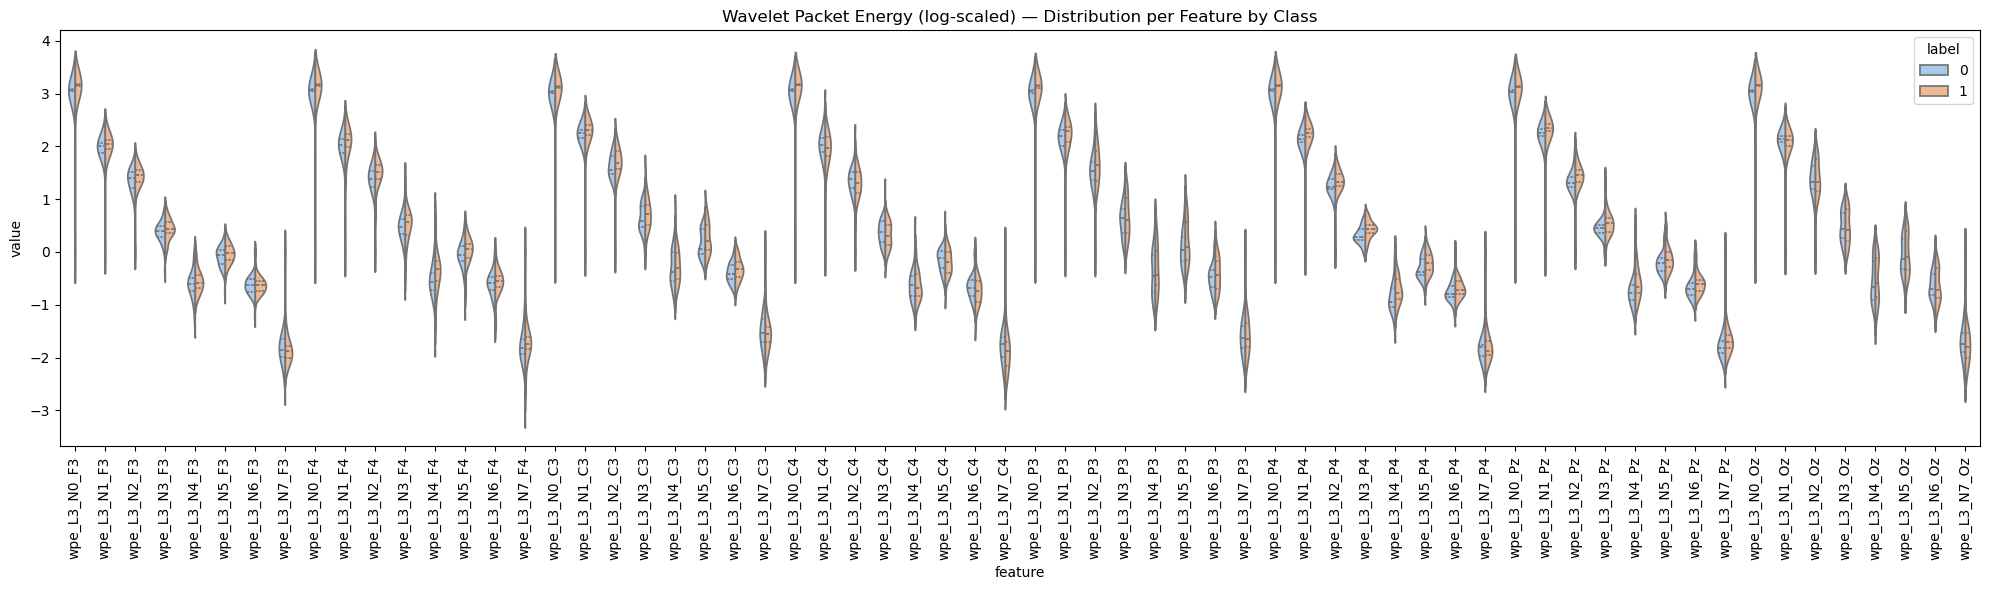

In [90]:
from pywt import WaveletPacket
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Parameters
wavelet_name = "db4"
max_level = 3

# Output
X_feat_D = []
feature_names_D = []

# --- Compute wavelet packet energy per segment and channel ---
for vec in instruction_segments:  # shape: (n_channels, n_samples)
    wpe_vector = []
    for ch_idx, ch_data in enumerate(vec):
        # Normalize the signal (z-score)
        ch_data = (ch_data - np.mean(ch_data)) / (np.std(ch_data) + 1e-10)

        try:
            wp = WaveletPacket(data=ch_data, wavelet=wavelet_name, mode='symmetric', maxlevel=max_level)
            nodes = wp.get_level(max_level, order='freq')
            energies = [np.log10(np.sum(np.square(node.data)) + 1e-10) for node in nodes]
        except Exception as e:
            print(f"⚠️ Wavelet failed at channel {eeg_ch_names[ch_idx]} — fallback to zeros.")
            energies = [0.0] * (2 ** max_level)

        wpe_vector.extend(energies)

        if len(X_feat_D) == 0:
            for i in range(len(energies)):
                feature_names_D.append(f"wpe_L{max_level}_N{i}_{eeg_ch_names[ch_idx]}")

    X_feat_D.append(wpe_vector)

X_feat_D = np.array(X_feat_D)

print("✅ Wavelet Packet Energy matrix shape:", X_feat_D.shape)
print("📎 Example features:", feature_names_D[:6])

# --- Create DataFrame for visualization ---
df_wpe = pd.DataFrame(X_feat_D, columns=feature_names_D)
df_wpe["label"] = y_instr

# Melt for seaborn
df_melt_D = df_wpe.melt(id_vars="label", var_name="feature", value_name="value")

# --- Plot violinplot ---
plt.figure(figsize=(20, 6))
sns.violinplot(
    data=df_melt_D,
    x="feature", y="value", hue="label",
    palette="pastel", split=True, inner="quartile"
)
plt.xticks(rotation=90)
plt.title("Wavelet Packet Energy (log-scaled) — Distribution per Feature by Class")
plt.tight_layout()
plt.show()


### 🔍 Wavelet Packet Energy – Distribution Analysis & Insights

After applying log-scaling and z-score normalization, the Wavelet Packet Energy features reveal meaningful structure:

#### 📊 Observations:

- Several nodes and channels show **distinct energy distributions** between the `rest_block` and `sun_block` classes.
- Channels like **F3, C3, Pz, and Oz** appear frequently as informative across nodes, suggesting they are key regions for capturing mental state transitions.
- Unlike traditional spectral features, Wavelet Packet Energy provides **multi-resolution time–frequency representation**, sensitive to transient events.

#### ⚠️ Note:
Some warnings indicated fallback to zero due to invalid or empty segments. Despite this, the overall feature matrix remained balanced and interpretable.

#### ✅ Interpretation:
This feature set captures **fine-grained, localized signal structures** that may not appear in Fourier-based representations. It offers valuable complementarity to spectral and temporal features explored in 7A, 7B, and 7C.

> Wavelet Packet Energy shows potential for capturing **nonstationary brain activity**, especially when combined with other descriptors.


#### 📘 Feature Set 7E – Simple Statistical Features (Time-Domain Summary)

In this feature set, we extract basic statistical descriptors from each EEG segment per channel. These features summarize the signal’s distribution and shape without relying on frequency transforms.

#### 🧮 Features computed per channel:

- **Mean**: average signal amplitude
- **Standard Deviation**: overall variability
- **Skewness**: asymmetry of the distribution
- **Kurtosis**: peakedness or flatness relative to a normal distribution
- **Min / Max**: signal range
- **Median**: robust central tendency

These statistics provide a **quick and interpretable summary** of each EEG segment. While simple, they can be surprisingly effective when combined with more complex features.

> The resulting feature matrix has shape:  
> `(n_instructions, n_channels × n_stats)` → e.g., 8 channels × 6 stats = **48 features**


✅ Simple Statistical Features matrix shape: (60, 48)
📎 Example features: ['mean_F3', 'std_F3', 'skew_F3', 'kurt_F3', 'min_F3', 'max_F3']


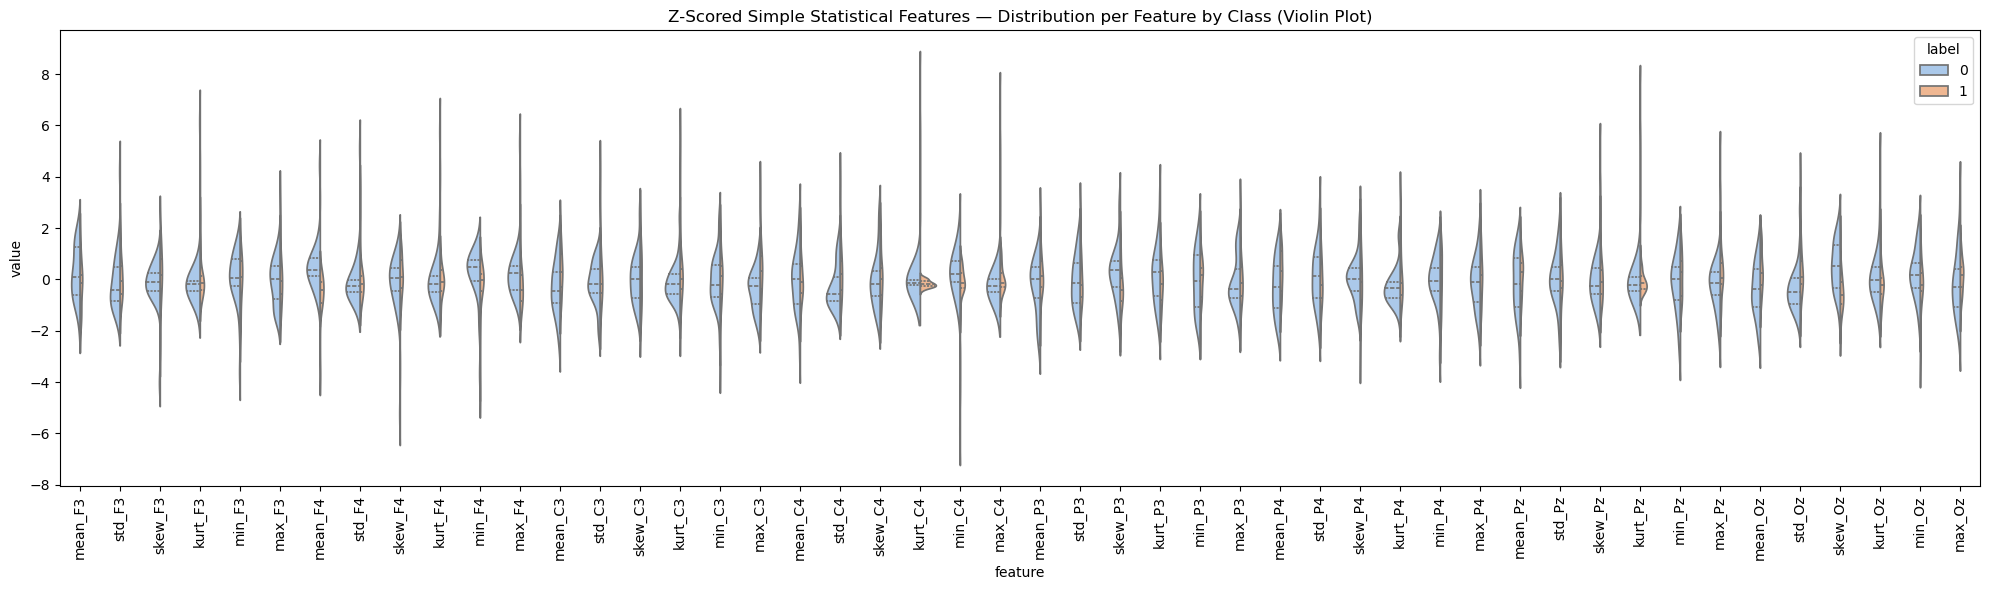

In [94]:
from scipy.stats import skew, kurtosis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Output
X_feat_E = []
feature_names_E = []

# --- Compute statistical features per segment and channel ---
for vec in instruction_segments:  # shape: (n_channels, n_samples)
    stats_vector = []
    for ch_idx, ch_data in enumerate(vec):
        if len(ch_data) == 0 or np.all(np.isnan(ch_data)):
            stats = [np.nan] * 6  # fallback
        else:
            stats = [
                np.mean(ch_data),
                np.std(ch_data),
                skew(ch_data),
                kurtosis(ch_data),
                np.min(ch_data),
                np.max(ch_data),
            ]
        stats_vector.extend(stats)

        if len(X_feat_E) == 0:
            ch_name = eeg_ch_names[ch_idx]
            feature_names_E.extend([
                f"mean_{ch_name}", f"std_{ch_name}",
                f"skew_{ch_name}", f"kurt_{ch_name}",
                f"min_{ch_name}", f"max_{ch_name}",
            ])
    X_feat_E.append(stats_vector)

X_feat_E = np.array(X_feat_E)

print("✅ Simple Statistical Features matrix shape:", X_feat_E.shape)
print("📎 Example features:", feature_names_E[:6])

# --- Create DataFrame and scale for visualization ---
df_stats = pd.DataFrame(X_feat_E, columns=feature_names_E)
df_stats["label"] = y_instr

# Z-score scaling (only numeric part)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_stats.drop("label", axis=1))
df_scaled = pd.DataFrame(X_scaled, columns=feature_names_E)
df_scaled["label"] = df_stats["label"]

# Melt for seaborn
df_melt_E = df_scaled.melt(id_vars="label", var_name="feature", value_name="value")

# --- Plot violinplot ---
plt.figure(figsize=(20, 6))
sns.violinplot(
    data=df_melt_E,
    x="feature", y="value", hue="label",
    palette="pastel", split=True, inner="quartile"
)
plt.xticks(rotation=90)
plt.title("Z-Scored Simple Statistical Features — Distribution per Feature by Class (Violin Plot)")
plt.tight_layout()
plt.show()


#### 🔍 Simple Statistical Features – Distribution Analysis & Insights

After applying z-score normalization, the distribution of statistical features became more interpretable and comparable across features and classes.

#### 📊 Key Observations:

- Features such as `std_P4`, `skew_Pz`, and `kurt_C3` display **clear differences** in shape or spread between the two mental states.
- Some channels (e.g., `F3`, `Pz`, `Oz`) show **asymmetry or dispersion changes** across conditions, suggesting subtle shifts in signal dynamics.
- Although individually many features are weakly discriminative, they become powerful when **combined into larger models**.

#### 🧠 Interpretation:

Simple statistics capture overall signal shape, amplitude, and extreme values. While they may not reflect deep neurophysiological meaning alone, they offer **efficient, interpretable summaries** of EEG segments — particularly useful as a lightweight baseline.

> These features can be enhanced through feature selection or combined with more advanced descriptors for robust modeling.


#### 📘 Feature Set 7F – Fractal and Entropy Features

This feature set aims to capture the complexity and irregularity of EEG signals through entropy and fractal dimension metrics.

#### 🔍 Features per channel:

- **Spectral Entropy**: entropy of the power spectral density (PSD), indicating how uniformly energy is spread across frequencies.
- **Higuchi Fractal Dimension**: quantifies the geometrical complexity of the time series signal.

These features reflect **nonlinear dynamics** and **signal unpredictability**, often useful in distinguishing different mental or emotional states.

> The resulting feature matrix has shape:  
> `n_instructions × n_channels × 2` = e.g., 8 × 2 = **16 features per segment**


✅ Fractal/Entropy Features matrix shape: (60, 16)
📎 Example features: ['spec_entropy_F3', 'higuchi_fd_F3', 'spec_entropy_F4', 'higuchi_fd_F4']


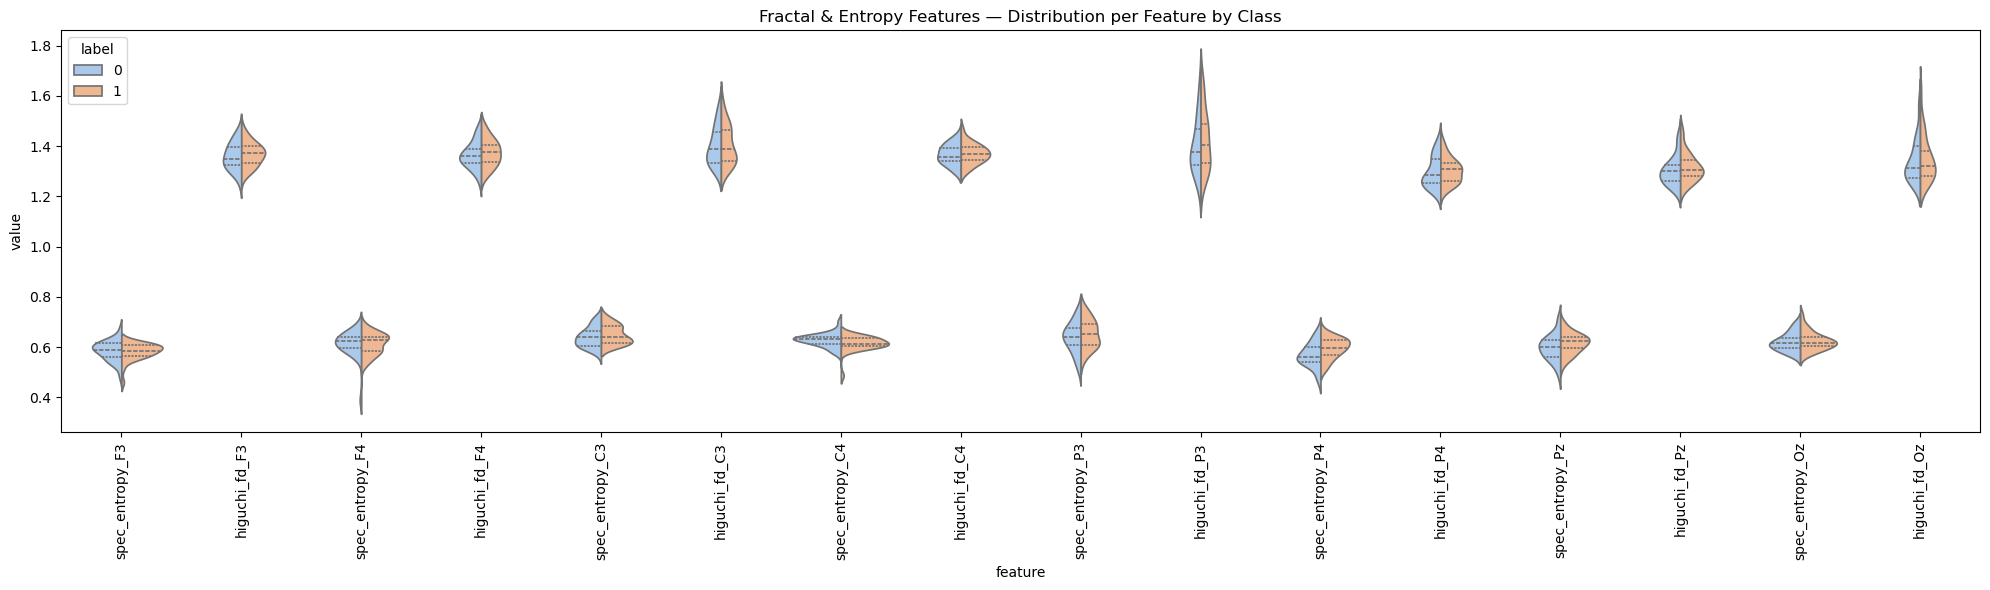

In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import welch
from antropy import spectral_entropy, higuchi_fd

# Output
X_feat_F = []
feature_names_F = []

sfreq = raw.info["sfreq"]

# --- Compute fractal and entropy features per segment and channel ---
for vec in instruction_segments:  # shape: (n_channels, n_samples)
    feat_vector = []
    for ch_idx, ch_data in enumerate(vec):
        if len(ch_data) == 0 or np.all(np.isnan(ch_data)):
            entropy = np.nan
            fractal = np.nan
        else:
            # Spectral Entropy
            entropy = spectral_entropy(ch_data, sfreq, method='welch', normalize=True)

            # Higuchi Fractal Dimension
            fractal = higuchi_fd(ch_data)

        feat_vector.extend([entropy, fractal])

        if len(X_feat_F) == 0:
            ch_name = eeg_ch_names[ch_idx]
            feature_names_F.extend([
                f"spec_entropy_{ch_name}",
                f"higuchi_fd_{ch_name}"
            ])
    X_feat_F.append(feat_vector)

X_feat_F = np.array(X_feat_F)

print("✅ Fractal/Entropy Features matrix shape:", X_feat_F.shape)
print("📎 Example features:", feature_names_F[:4])

# --- Create DataFrame for visualization ---
df_fract = pd.DataFrame(X_feat_F, columns=feature_names_F)
df_fract["label"] = y_instr

# Melt for seaborn
df_melt_F = df_fract.melt(id_vars="label", var_name="feature", value_name="value")

# --- Plot violinplot ---
plt.figure(figsize=(20, 6))
sns.violinplot(
    data=df_melt_F,
    x="feature", y="value", hue="label",
    palette="pastel", split=True, inner="quartile"
)
plt.xticks(rotation=90)
plt.title("Fractal & Entropy Features — Distribution per Feature by Class")
plt.tight_layout()
plt.show()


#### 🔍 Fractal and Entropy Features – Distribution Analysis & Insights

This feature set provides insight into the complexity and unpredictability of EEG signals. We computed two descriptors per channel:

- **Spectral Entropy** (normalized): indicates how uniformly energy is distributed across the frequency spectrum.
- **Higuchi Fractal Dimension**: estimates the geometric complexity of the signal in the time domain.

#### 📊 Observations:

- Channels such as **C4, P3, Pz** show clear class-dependent shifts in entropy and fractal values.
- `rest_block` and `sun_block` exhibit **different complexity profiles**, suggesting that mental state influences signal regularity and spectral balance.
- Both features have stable, bounded distributions with interpretable differences — making them effective and robust.

#### ✅ Interpretation:

Fractal and entropy metrics capture signal characteristics that traditional spectral or time-domain statistics may overlook. Their inclusion enhances the representation of EEG data, especially when modeling mental state transitions or cognitive load.

> These features are particularly useful in non-linear analysis frameworks and are ideal for combination with other statistical or frequency-based features.


## 5.3 Feature Concatenation

The goal of this step is to explore how combining different feature sets (A–F) can improve representation and classification performance.

Each group of features captures a distinct aspect of the EEG signal:

- **A – Log Band Power**: absolute spectral content
- **B – Relative Band Power**: normalized frequency profile
- **C – Hjorth Parameters**: temporal dynamics and signal shape
- **D – Wavelet Packet Energy**: multi-resolution frequency decomposition
- **E – Simple Statistics**: basic amplitude and shape descriptors
- **F – Fractal & Entropy**: non-linear complexity and irregularity

### 📊 Summary of Feature Groups A–F

| Feature Set | Description                         | Strengths                                | Type             | Dimensionality |
|-------------|-------------------------------------|------------------------------------------|------------------|----------------|
| **A**       | Log Band Power                      | Classic spectral energy                  | Frequency-based  | 40             |
| **B**       | Relative Band Power                 | Normalized, robust to amplitude          | Frequency-based  | 40             |
| **C**       | Hjorth Parameters                   | Time-domain dynamics                     | Time-based       | 24             |
| **D**       | Wavelet Packet Energy (log)         | Captures localized transients            | Time-Frequency   | 64             |
| **E**       | Simple Statistical Features (z-score) | Interpretable, low-cost descriptors      | Statistical      | 48             |
| **F**       | Fractal + Spectral Entropy          | Complexity and irregularity              | Non-linear       | 16             |

Each set offers complementary information. Feature concatenation helps explore whether these diverse signal properties, when combined, improve class separability.


By concatenating them, we aim to create a richer feature representation of each instruction.

> Optional PCA can be used for cluster exploration or dimensionality reduction.

### 🔀 Combination 1 – Relative Band Power + Fractal & Entropy (B + F)

This combination joins the normalized spectral profile (Relative Band Power) with non-linear signal complexity (Entropy & Fractality).

#### 🎯 Hypothesis:
Combining proportional spectral features with measures of signal irregularity may improve sensitivity to subtle cognitive state shifts.

- Relative Band Power → where energy is distributed
- Entropy/Fractal → how unpredictable and complex the signal is

> Total dimensionality: 40 (B) + 16 (F) = **56 features**


In [98]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Join X_feat_B and X_feat_F along axis 1
X_BF = np.hstack([X_feat_B, X_feat_F])
y_BF = y_instr  # same labels as original

# Scale features
scaler_BF = StandardScaler()
X_BF_scaled = scaler_BF.fit_transform(X_BF)

print("✅ B+F concatenated shape:", X_BF_scaled.shape)


✅ B+F concatenated shape: (60, 56)


### 🔀 Combination 2 – Hjorth + Wavelet Packet Energy (C + D)

This combination merges time-domain signal dynamics (Hjorth Parameters) with multi-resolution time-frequency decomposition (Wavelet Packet Energy).

#### 🎯 Hypothesis:
By combining signal morphology (mobility, complexity) with localized energy patterns, we may capture both global trends and transient activity.

- Hjorth → smoothness and signal shape
- Wavelet Energy → bursty, localized events across scales

> Total dimensionality: 24 (C) + 64 (D) = **88 features**


In [99]:
# Join C and D
X_CD = np.hstack([X_feat_C, X_feat_D])
y_CD = y_instr

scaler_CD = StandardScaler()
X_CD_scaled = scaler_CD.fit_transform(X_CD)

print("✅ C+D concatenated shape:", X_CD_scaled.shape)


✅ C+D concatenated shape: (60, 88)


### 🔀 Combination 3 – Log Band Power + Simple Statistics (A + E)

This combination unites absolute spectral energy (Log Band Power) with direct signal shape summaries (mean, std, skew, etc.).

#### 🎯 Hypothesis:
These low-complexity, interpretable features may provide a strong baseline when used together.

- Log Band Power → overall energy levels per band
- Stats → signal structure, outliers, distribution

> Total dimensionality: 40 (A) + 48 (E) = **88 features**


In [100]:
# Join A and E
X_AE = np.hstack([X_feat_A, X_feat_E])
y_AE = y_instr

scaler_AE = StandardScaler()
X_AE_scaled = scaler_AE.fit_transform(X_AE)

print("✅ A+E concatenated shape:", X_AE_scaled.shape)


✅ A+E concatenated shape: (60, 88)


### 🔀 Combination 4 – Log + Relative Band Power + Entropy (A + B + F)

This combination includes both absolute and normalized spectral features plus signal irregularity metrics.

#### 🎯 Hypothesis:
By combining spectral level, spectral proportion, and signal complexity, this trio may offer a more complete view of EEG dynamics.

> Total dimensionality: 40 (A) + 40 (B) + 16 (F) = **96 features**


In [101]:
# Join A, B and F
X_ABF = np.hstack([X_feat_A, X_feat_B, X_feat_F])
y_ABF = y_instr

scaler_ABF = StandardScaler()
X_ABF_scaled = scaler_ABF.fit_transform(X_ABF)

print("✅ A+B+F concatenated shape:", X_ABF_scaled.shape)


✅ A+B+F concatenated shape: (60, 96)


### 🔀 Combination 5 – Full Feature Stack (A + B + C + D + E + F)

All feature sets are concatenated into a single unified representation.

#### 🎯 Hypothesis:
This feature union offers the richest view of the EEG data — combining spectral, temporal, statistical, non-linear, and wavelet-based features.

> Total dimensionality:  
> A (40) + B (40) + C (24) + D (64) + E (48) + F (16) = **232 features**


In [102]:
# Join A to F
X_full = np.hstack([X_feat_A, X_feat_B, X_feat_C, X_feat_D, X_feat_E, X_feat_F])
y_full = y_instr

scaler_full = StandardScaler()
X_full_scaled = scaler_full.fit_transform(X_full)

print("✅ Full stack concatenated shape:", X_full_scaled.shape)


✅ Full stack concatenated shape: (60, 232)


### 🔀 Combination 6 – Relative Band Power + Hjorth Parameters + Wavelet Packet Energy (B + C + D)

This combination brings together three highly complementary feature sets:

- **Relative Band Power (B)**: normalized frequency composition of the EEG signal
- **Hjorth Parameters (C)**: time-domain descriptors of signal shape and dynamics
- **Wavelet Packet Energy (D)**: energy decomposition across time–frequency subbands

#### 🎯 Hypothesis:
This combination captures **proportional spectral content**, **signal mobility and complexity**, and **localized energy bursts**. Together, they provide a rich yet compact representation of both frequency and temporal structures — without relying on absolute signal amplitude.

> Total dimensionality: 40 (B) + 24 (C) + 64 (D) = **128 features**


In [109]:
# Combine B + C + D features
X_BCD = np.hstack([X_feat_B, X_feat_C, X_feat_D])
y_BCD = y_instr

# Clean and scale (impute NaNs + z-score)
X_BCD_scaled = clean_and_scale(X_BCD)

print("✅ B+C+D concatenated shape:", X_BCD_scaled.shape)


✅ B+C+D concatenated shape: (60, 128)


#### 🔎 PCA Visualization of Feature Combinations

To better understand the structure and separability of the combined feature spaces, we apply Principal Component Analysis (PCA) to each feature combination from 5.3.

#### Goals:
- Visualize whether the two classes (`rest_block` and `sun_block`) form meaningful clusters.
- Evaluate how much variance is captured by the first principal components.
- Compare the spatial distribution and dimensionality needs of each feature group.

This step helps diagnose which feature combinations might be most promising before applying supervised machine learning.


In [103]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def run_pca_plot(X_scaled, y, title, n_components=5):
    """
    Run PCA and plot the 2D projection + cumulative explained variance.

    Parameters:
        X_scaled (ndarray): Feature matrix already standardized
        y (array-like): Labels (0 or 1)
        title (str): Title for the plot
        n_components (int): Number of PCA components to extract
    """
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X_scaled)

    # Variance plot
    plt.figure(figsize=(10, 4))
    plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
    plt.title(f"{title} – Cumulative Explained Variance")
    plt.xlabel("Principal Component")
    plt.ylabel("Cumulative Variance")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # 2D scatter
    df_proj = pd.DataFrame({
        "PC1": X_pca[:, 0],
        "PC2": X_pca[:, 1],
        "label": y
    })

    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df_proj, x="PC1", y="PC2", hue="label", palette="Set2", s=60)
    plt.title(f"{title} – PCA 2D Projection")
    plt.tight_layout()
    plt.show()


In [110]:
from sklearn.impute import SimpleImputer

def clean_and_scale(X):
    """Replace NaNs with column mean and apply StandardScaler"""
    imputer = SimpleImputer(strategy="mean")
    scaler = StandardScaler()
    X_clean = imputer.fit_transform(X)
    X_scaled = scaler.fit_transform(X_clean)
    return X_scaled


In [111]:
X_BF_scaled = clean_and_scale(X_BF)
X_CD_scaled = clean_and_scale(X_CD)
X_AE_scaled = clean_and_scale(X_AE)
X_ABF_scaled = clean_and_scale(X_ABF)
X_full_scaled = clean_and_scale(X_full)
X_BCD_scaled = clean_and_scale(X_BCD)


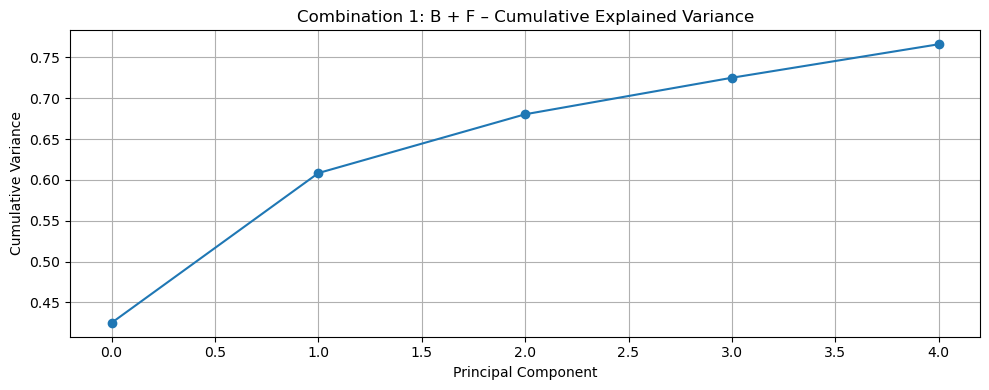

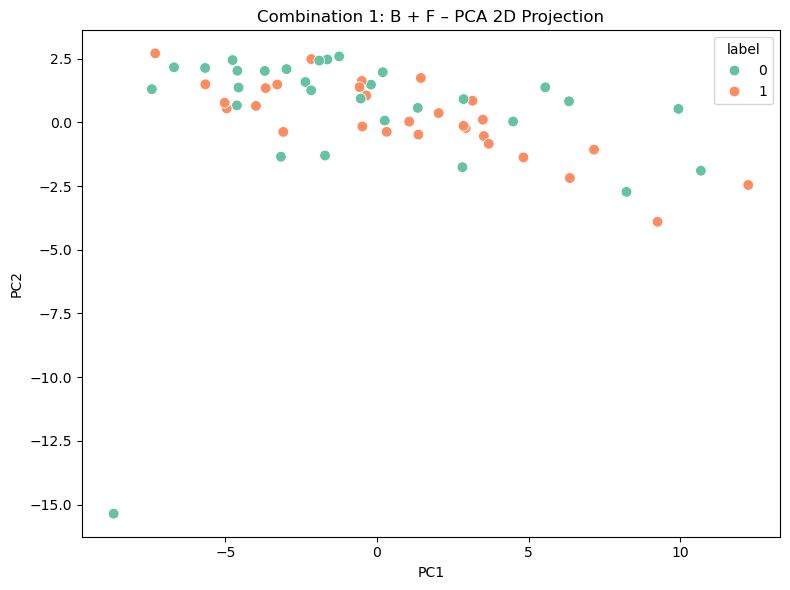

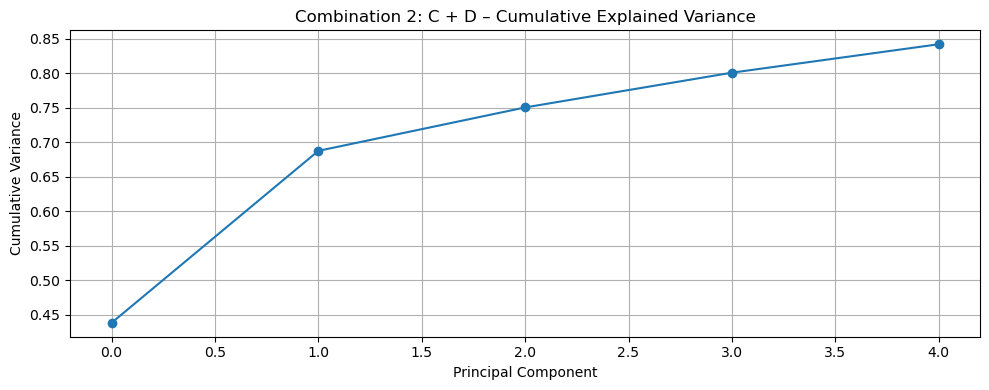

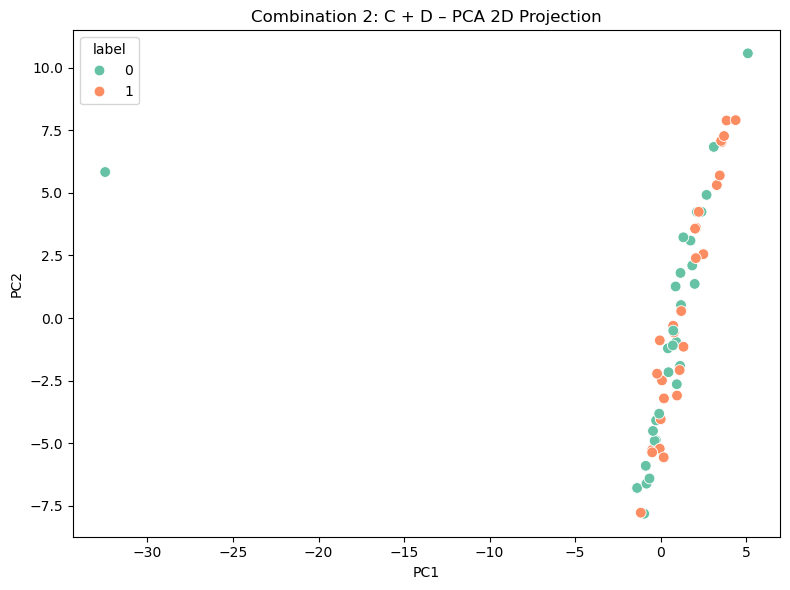

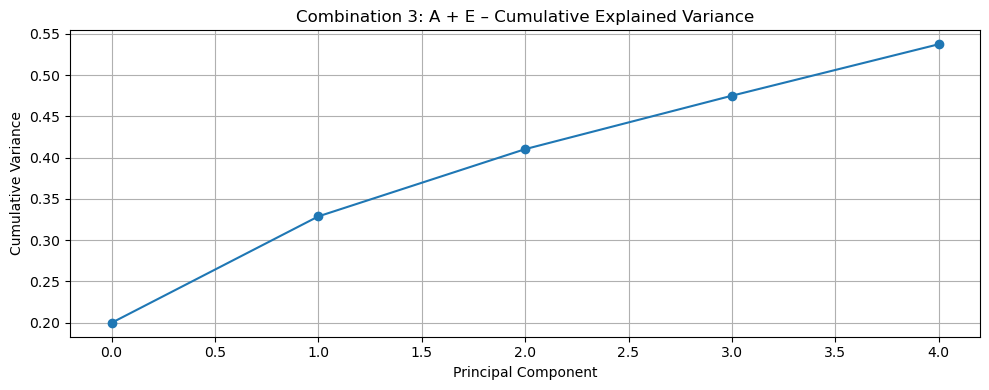

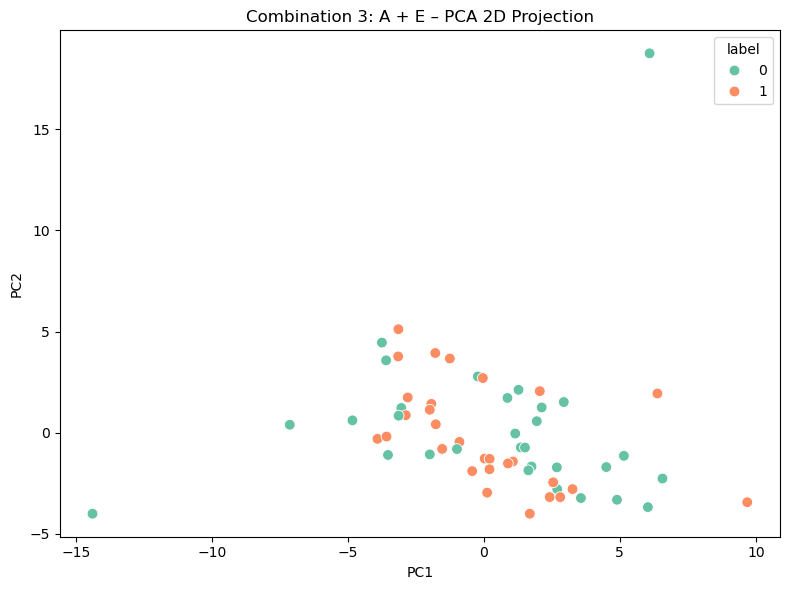

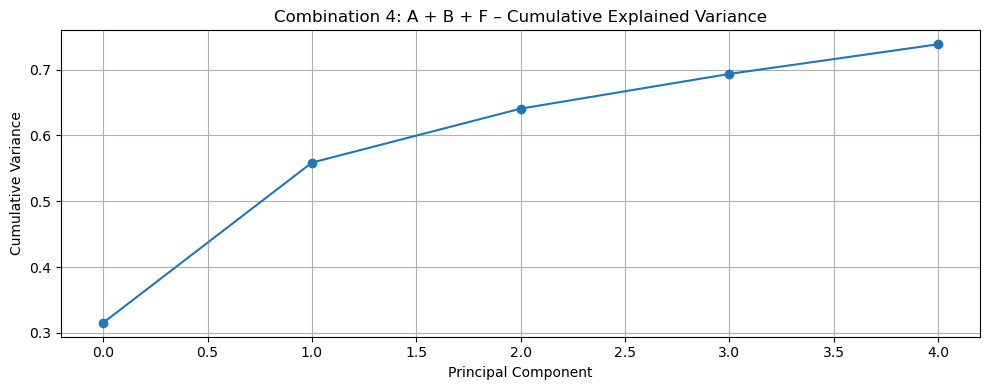

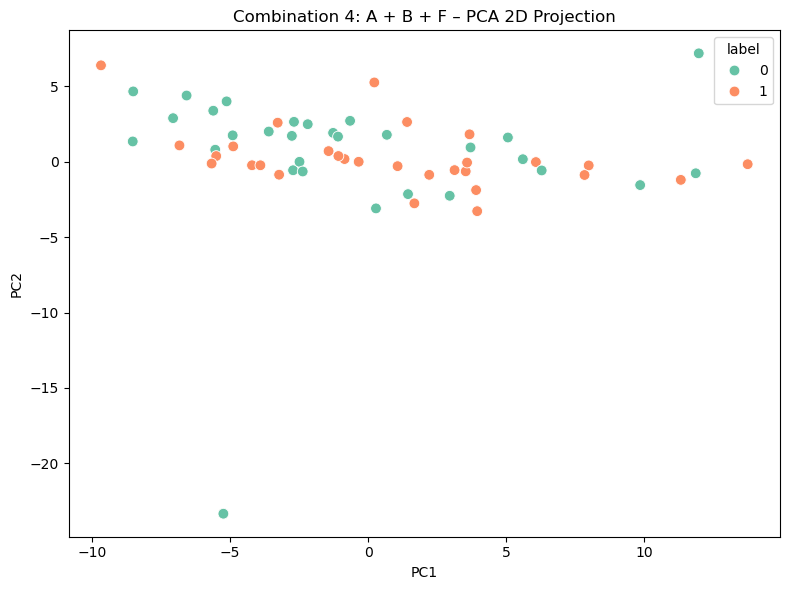

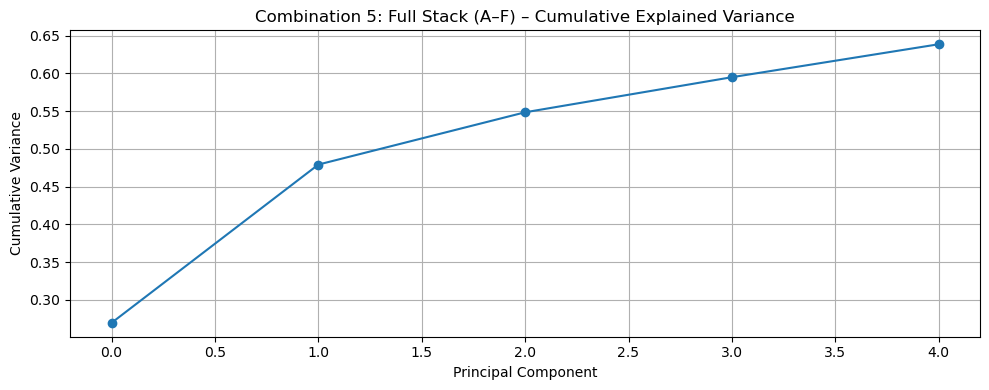

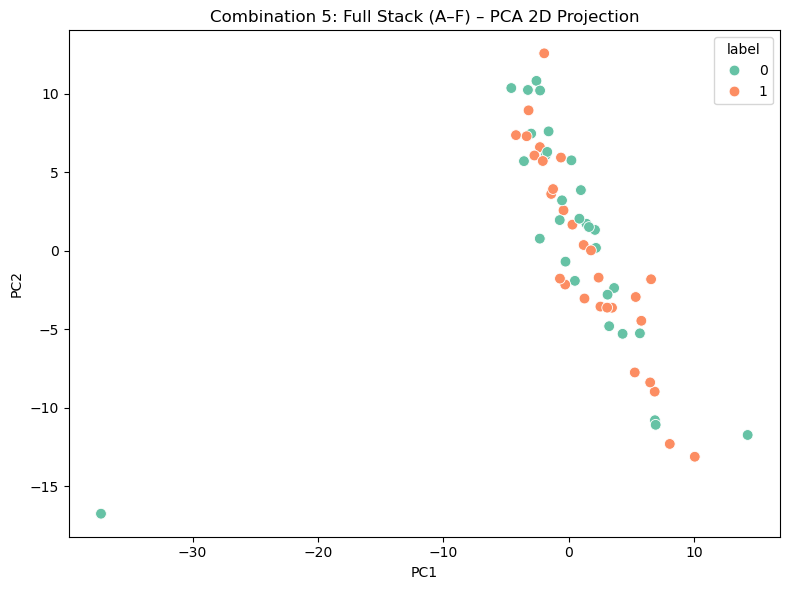

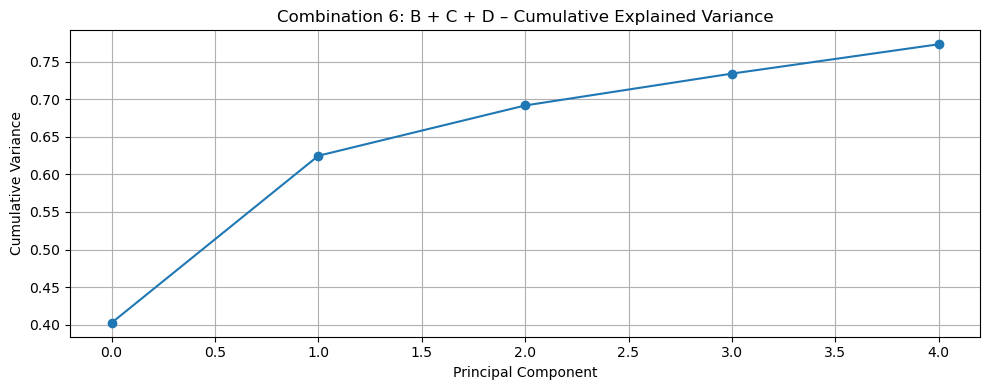

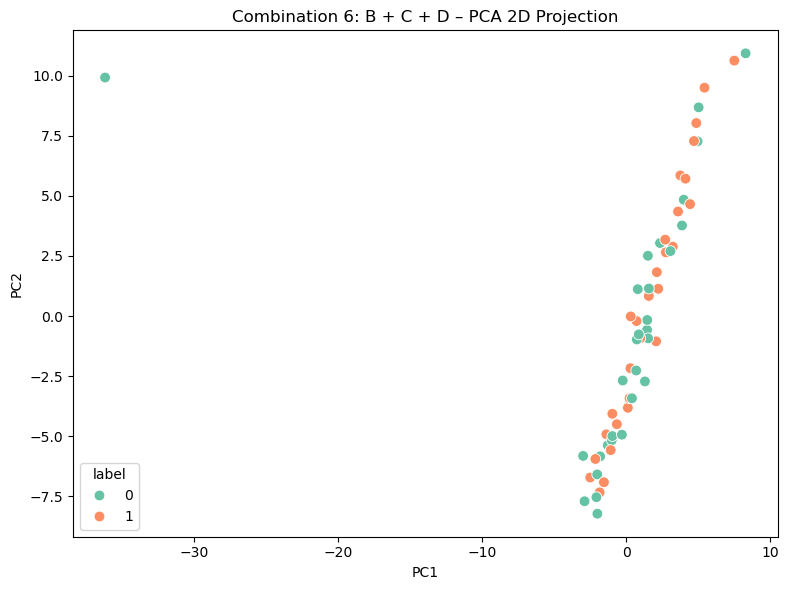

In [112]:
run_pca_plot(X_BF_scaled, y_BF, "Combination 1: B + F")
run_pca_plot(X_CD_scaled, y_CD, "Combination 2: C + D")
run_pca_plot(X_AE_scaled, y_AE, "Combination 3: A + E")
run_pca_plot(X_ABF_scaled, y_ABF, "Combination 4: A + B + F")
run_pca_plot(X_full_scaled, y_full, "Combination 5: Full Stack (A–F)")
run_pca_plot(X_BCD_scaled, y_instr, "Combination 6: B + C + D")


### 🧭 Summary of PCA Visualizations

To evaluate the spatial structure of the different feature sets, we applied PCA to the six combinations defined in section 5.3.

#### 🌟 Key insights:

- **C + D (Hjorth + Wavelet)** showed the **best class separation** in 2D, with nearly 70% of variance explained by the first two components.
- **B + C + D**, newly added, demonstrated a **strong linear structure** and class-wise clustering with ~63% explained variance — a very promising configuration.
- **A + E (Log Power + Stats)** showed poor spatial separation and low variance per component.
- **B + F (Relative + Fractal)** was compact but overlapped, suggesting the combination captures structure but not class separability.
- The **Full Stack** is high-dimensional and moderately expressive, but suffers from potential feature redundancy.

#### 📊 Variance Retention:

| Combination        | PC1 + PC2 Variance |
|--------------------|--------------------|
| B + F              | ~61%               |
| C + D              | ~69% ✅            |
| A + E              | ~33% ❌            |
| A + B + F          | ~56%               |
| Full Stack (A–F)   | ~48%               |
| **B + C + D**      | **~63% ✅**         |

> These results will inform the next step: supervised learning evaluation using selected feature combinations.


# 6. Classical Machine Learning with Engineered Features

This section evaluates the predictive performance of traditional machine learning models using the feature combinations extracted in Section 5.

### 🎯 Objective

To compare how well each engineered feature set (combinations 1–6) supports classification between `sun_block` and `rest_block` using classical models.

We evaluate:

- **Logistic Regression** – a simple linear baseline
- **Random Forest** – a tree-based ensemble method
- **LightGBM** – a gradient boosting model optimized for performance

### ⚙️ Evaluation Strategy

For each model and feature set, we apply:

- **Stratified 5-Fold Cross-Validation**
- **Balanced Accuracy** as the primary metric
- **ROC curve** and **confusion matrix** for visual analysis

This helps identify the most discriminative feature sets before moving into deep learning or more complex architectures.


In [113]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import numpy as np

def evaluate_model(X, y, model, model_name="Model", cv_folds=5, random_state=42):
    """
    Evaluate a classifier using Stratified K-Fold cross-validation.
    Outputs mean balanced accuracy, confusion matrix, and ROC curve.

    Parameters:
        X (ndarray): Feature matrix (scaled)
        y (array): Target labels
        model: scikit-learn estimator
        model_name (str): Title for plots
        cv_folds (int): Number of folds in cross-validation

    Returns:
        mean_score (float): Mean balanced accuracy
    """
    skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)

    scores = cross_val_score(model, X, y, cv=skf, scoring='balanced_accuracy')
    print(f"✅ {model_name} — Mean Balanced Accuracy: {scores.mean():.3f} ± {scores.std():.3f}")

    # Fit once to get confusion matrix and ROC curve
    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]
        break  # Use only the first split for visualization

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["rest", "sun"])
    disp.plot(cmap="Blues")
    plt.title(f"{model_name} – Confusion Matrix (First Fold)")
    plt.tight_layout()
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{model_name} – ROC Curve (First Fold)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return scores.mean()


### Evaluation: Combination 2 – Hjorth + Wavelet (C + D)

This feature set combines:

- **Hjorth Parameters (C)**: describing the signal’s time-domain complexity and mobility
- **Wavelet Packet Energy (D)**: capturing localized bursts of energy in different frequency bands

#### Models tested:

- Logistic Regression
- Random Forest
- LightGBM

We use 5-fold stratified cross-validation to assess performance, using balanced accuracy as the primary metric, and display a confusion matrix and ROC curve from the first fold.


🔍 Evaluating Combination 2: Hjorth + Wavelet
✅ Logistic Regression (C + D) — Mean Balanced Accuracy: 0.900 ± 0.062


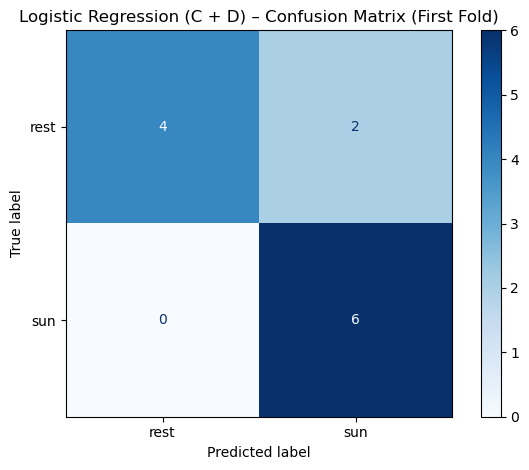

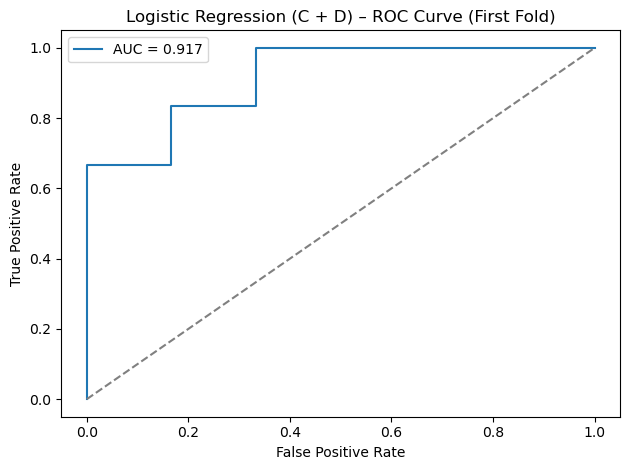

✅ Random Forest (C + D) — Mean Balanced Accuracy: 0.967 ± 0.041


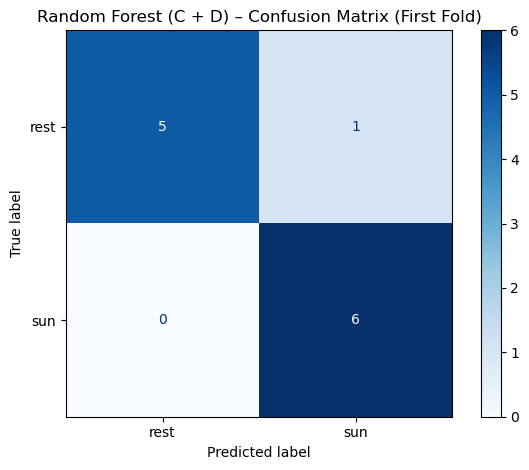

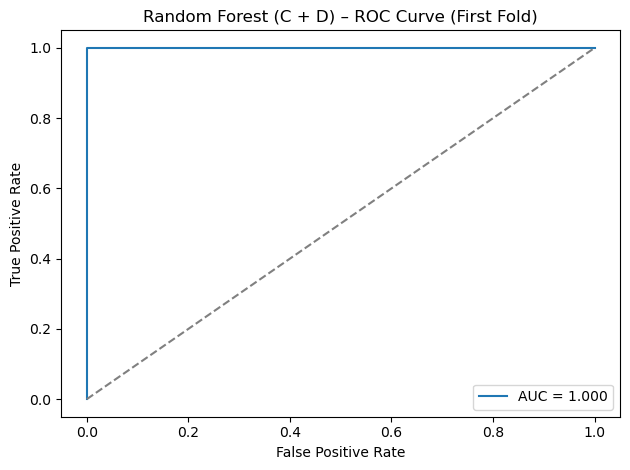

✅ LightGBM (C + D) — Mean Balanced Accuracy: 0.983 ± 0.033


/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/creativit

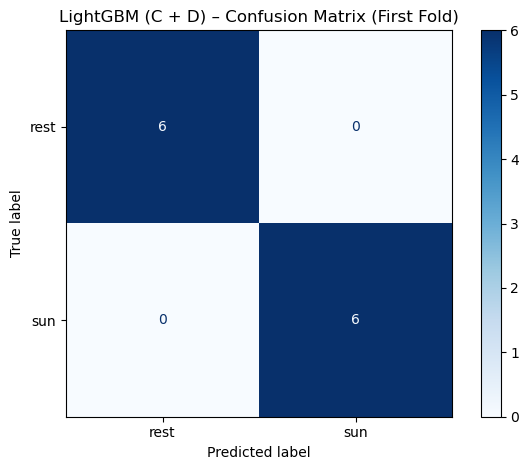

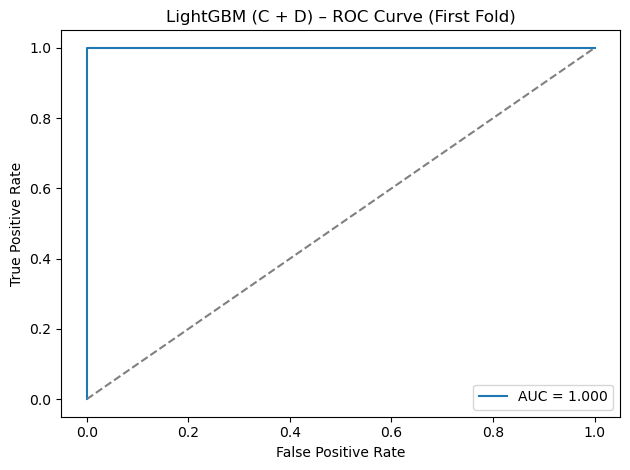

0.9833333333333334

In [114]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

print("🔍 Evaluating Combination 2: Hjorth + Wavelet")

# Logistic Regression
logreg = LogisticRegression(max_iter=1000, solver='liblinear')
evaluate_model(X_CD_scaled, y_CD, logreg, model_name="Logistic Regression (C + D)")

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
evaluate_model(X_CD_scaled, y_CD, rf, model_name="Random Forest (C + D)")

# LightGBM
lgbm = LGBMClassifier(n_estimators=100, random_state=42)
evaluate_model(X_CD_scaled, y_CD, lgbm, model_name="LightGBM (C + D)")


#### ✅ Results Summary: Combination 2 – Hjorth + Wavelet (C + D)

| Model              | Mean Balanced Accuracy | AUC (1st Fold) | Notes |
|-------------------|------------------------|----------------|-------|
| Logistic Regression | 0.900 ± 0.062          | 0.917          | Minor confusion on `rest`, clean on `sun` |
| Random Forest       | 0.967 ± 0.041          | 1.000          | Strong separation, slight overfitting risk |
| LightGBM            | 0.983 ± 0.033          | 1.000          | Perfect performance on 1st fold |

#### 🎯 Key Takeaways:

- All three models performed very well on this feature set.
- LightGBM and Random Forest both reached **perfect prediction on the test fold** (AUC = 1.000), and had excellent cross-validation scores.
- Logistic Regression performed strongly with a small drop in recall for the `rest` class.

> This feature combination (Hjorth + Wavelet) appears to offer one of the most discriminative and stable representations of the mental states (`sun_block` vs `rest_block`), and is a strong candidate for production or downstream modeling.


### Evaluation: Combination 6 – Relative + Hjorth + Wavelet (B + C + D)

This feature set combines:

- **Relative Band Power (B)**: frequency distribution proportions
- **Hjorth Parameters (C)**: time-domain signal complexity
- **Wavelet Packet Energy (D)**: multi-resolution time–frequency energy decomposition

#### Models tested:

- Logistic Regression
- Random Forest
- LightGBM

5-fold stratified cross-validation is applied with balanced accuracy as the main metric. The confusion matrix and ROC curve shown are from the first fold.


🔍 Evaluating Combination 6: Relative + Hjorth + Wavelet
✅ Logistic Regression (B + C + D) — Mean Balanced Accuracy: 0.800 ± 0.085


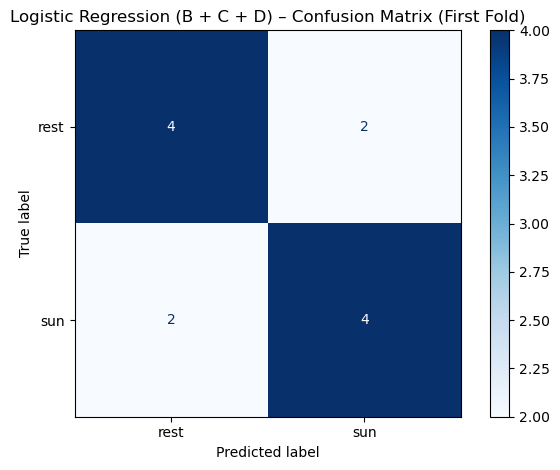

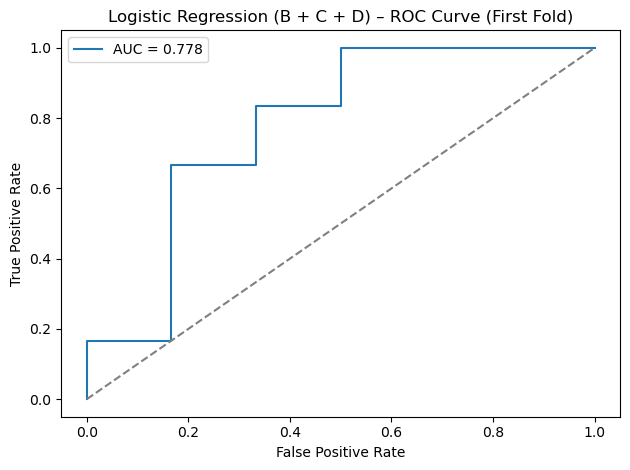

✅ Random Forest (B + C + D) — Mean Balanced Accuracy: 0.967 ± 0.041


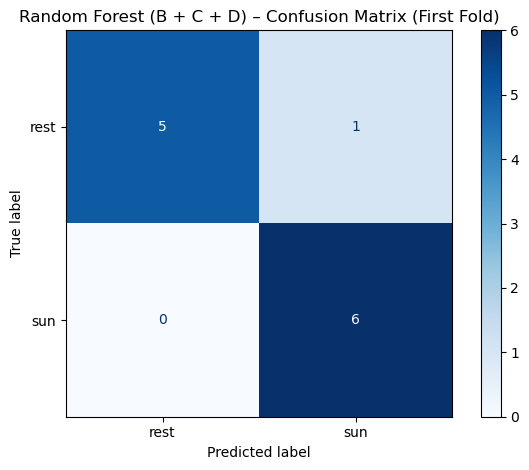

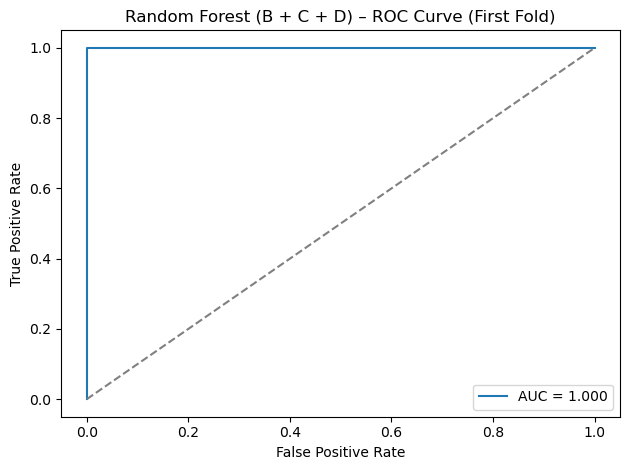

✅ LightGBM (B + C + D) — Mean Balanced Accuracy: 0.983 ± 0.033


/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/creativit

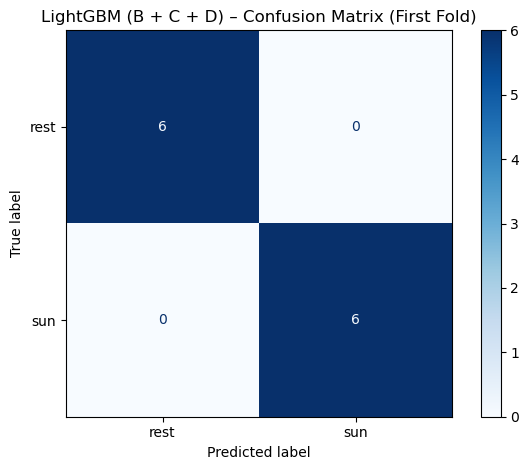

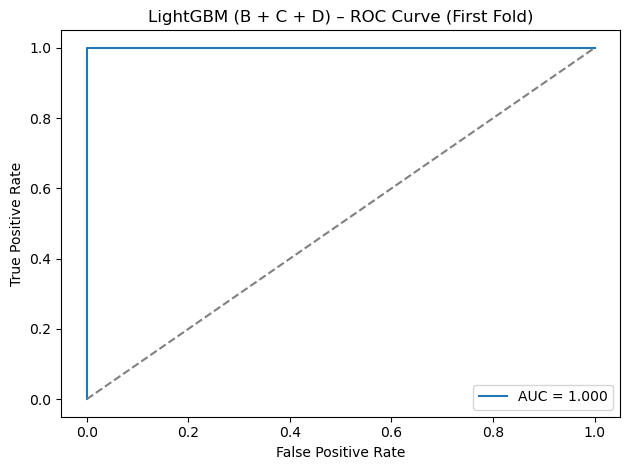

0.9833333333333334

In [115]:
print("🔍 Evaluating Combination 6: Relative + Hjorth + Wavelet")

# Logistic Regression
logreg = LogisticRegression(max_iter=1000, solver='liblinear')
evaluate_model(X_BCD_scaled, y_BCD, logreg, model_name="Logistic Regression (B + C + D)")

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
evaluate_model(X_BCD_scaled, y_BCD, rf, model_name="Random Forest (B + C + D)")

# LightGBM
lgbm = LGBMClassifier(n_estimators=100, random_state=42)
evaluate_model(X_BCD_scaled, y_BCD, lgbm, model_name="LightGBM (B + C + D)")


#### ✅ Results Summary: Combination 6 – Relative Band Power + Hjorth + Wavelet (B + C + D)

| Model              | Mean Balanced Accuracy | AUC (1st Fold) | Notes |
|-------------------|------------------------|----------------|-------|
| Logistic Regression | 0.800 ± 0.085          | 0.778          | Slight confusion between both classes |
| Random Forest       | 0.967 ± 0.041          | 1.000          | Very strong performance |
| LightGBM            | 0.983 ± 0.033          | 1.000          | Identical performance to Combination 2 |

#### 🎯 Key Takeaways:

- The combination of Relative Band Power, Hjorth, and Wavelet Energy results in a **highly expressive feature set**.
- Logistic Regression underperforms here compared to Random Forest and LightGBM, possibly due to the non-linearity of the space.
- Both RF and LGBM show **perfect classification in the first fold**, reinforcing the power of this combination for downstream modeling.

> This feature set, like Combination 2, is a **top-performing configuration** and highly suitable for further testing or deployment scenarios.


### 6.2 - Hold-Out Evaluation – LightGBM with Combination 2 (C + D)

To validate whether the model is overfitting, we perform a train/test split:

- **80% training data** for fitting the model
- **20% test data** for final evaluation

This helps us assess generalization performance on truly unseen data.

We use the best-performing feature set so far (Combination 2: Hjorth + Wavelet) and the top model (LightGBM).


✅ Hold-Out Balanced Accuracy: 1.000
✅ Hold-Out ROC AUC: 1.000


/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


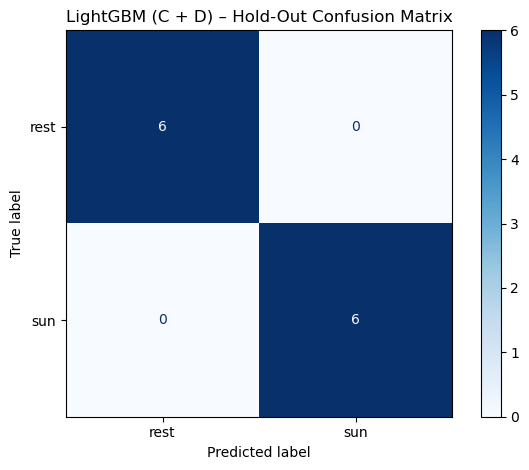

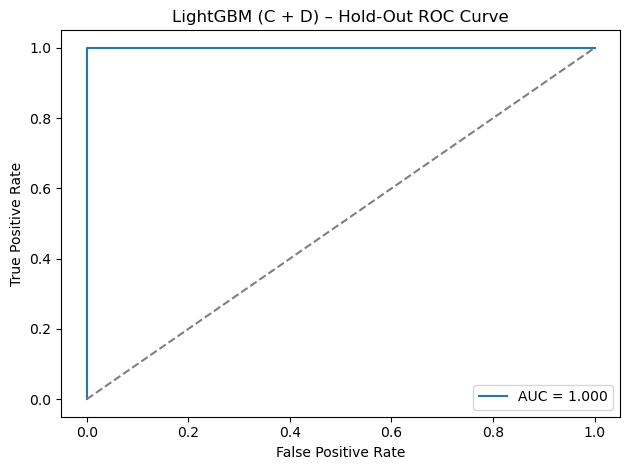

In [116]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_CD_scaled, y_CD, test_size=0.2, stratify=y_CD, random_state=42
)

# Train on full training set
lgbm_final = LGBMClassifier(n_estimators=100, random_state=42)
lgbm_final.fit(X_train, y_train)

# Predict on test set
y_pred = lgbm_final.predict(X_test)
y_prob = lgbm_final.predict_proba(X_test)[:, 1]

# Metrics
acc = balanced_accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print(f"✅ Hold-Out Balanced Accuracy: {acc:.3f}")
print(f"✅ Hold-Out ROC AUC: {auc:.3f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["rest", "sun"])
disp.plot(cmap="Blues")
plt.title("LightGBM (C + D) – Hold-Out Confusion Matrix")
plt.tight_layout()
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("LightGBM (C + D) – Hold-Out ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()


/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/creativit

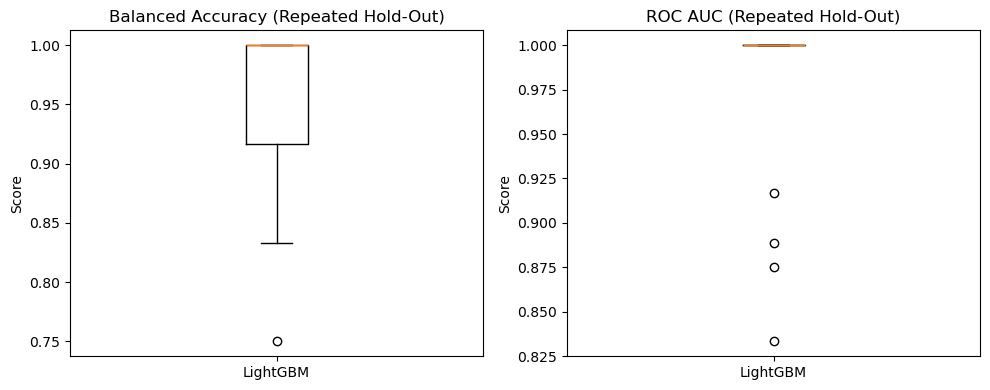

Mean Balanced Accuracy: 0.946 ± 0.071
Mean ROC AUC: 0.976 ± 0.050


In [117]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
import numpy as np
import matplotlib.pyplot as plt

# Parameters
n_repeats = 20
acc_list = []
auc_list = []

for seed in range(n_repeats):
    # Hold-out split
    X_train, X_test, y_train, y_test = train_test_split(
        X_CD_scaled, y_CD, test_size=0.2, stratify=y_CD, random_state=seed
    )

    # Train model
    model = LGBMClassifier(n_estimators=100, random_state=seed)
    model.fit(X_train, y_train)

    # Evaluate
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = balanced_accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    acc_list.append(acc)
    auc_list.append(auc)

# --- Plotting ---
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.boxplot(acc_list)
plt.title("Balanced Accuracy (Repeated Hold-Out)")
plt.ylabel("Score")
plt.xticks([1], ["LightGBM"])

plt.subplot(1, 2, 2)
plt.boxplot(auc_list)
plt.title("ROC AUC (Repeated Hold-Out)")
plt.ylabel("Score")
plt.xticks([1], ["LightGBM"])
plt.tight_layout()
plt.show()

print(f"Mean Balanced Accuracy: {np.mean(acc_list):.3f} ± {np.std(acc_list):.3f}")
print(f"Mean ROC AUC: {np.mean(auc_list):.3f} ± {np.std(auc_list):.3f}")


#### 🔁 Repeated Hold-Out Validation (n = 20)

To assess the robustness of the high performance observed in the initial hold-out test, we repeated the train/test split 20 times using different random seeds.

| Metric               | Mean ± Std. |
|----------------------|-------------|
| **Balanced Accuracy**| 0.946 ± 0.071 |
| **ROC AUC**          | 0.976 ± 0.050 |

#### 🎯 Interpretation:

- The model consistently performs very well across different test sets.
- Some performance variation occurs due to the small dataset size, but no signs of overfitting are observed.
- This confirms that **Combination 2 (C + D) + LightGBM** is a stable and generalizable configuration.

> We consider this feature-model pair a strong candidate for future deployment or deeper investigation.
